# 0. Contexto del proyecto
- **Objetivo:** Clasificación multiclase de las etapas del sueño (`Sleep_Stage`: W, N1, N2, N3, R) a partir de señales fisiológicas de Polisomnografía (PSG) y del wearable Empatica E4.
- **Frecuencia de muestreo:** 100 Hz (mediciones cada 10 ms). Un epoch estándar equivale a 30 segundos (3000 muestras).
- **Formato de archivos:** Archivos individuales por paciente con nomenclatura `SXXX_PSG_df.csv` (ej. `S005_PSG_df.csv`, donde `005` es el ID del participante).
- **Esquema de columnas (32 variables):**
  - *Temporal:* `TIMESTAMP`
  - *EEG / EOG / EMG / ECG (PSG):* `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4`, `CHIN`, `E1`, `E2`, `ECG`, `LAT`, `RAT`
  - *Respiratorias y Oximetría (PSG):* `SNORE`, `PTAF`, `FLOW`, `THORAX`, `ABDOMEN`, `SAO2`
  - *Wearable (Empatica E4):* `BVP`, `ACC_X`, `ACC_Y`, `ACC_Z`, `TEMP`, `EDA`, `HR`, `IBI`
  - *Eventos Clínicos (Apneas):* `Obstructive_Apnea`, `Central_Apnea`, `Hypopnea`, `Multiple_Events`
  - *Target:* `Sleep_Stage`
- **Fuente:** DREAMT 2.2.0, disponible en PhysioNet. La cantidad de archivos de pacientes depende de los datos disponibles en el entorno de ejecución.
- **Anotaciones:** las etapas de sueño fueron anotadas por especialistas cada 30 segundos. Las anotaciones de apnea se conservan en el origen, pero no se incluyen como predictores.

## 0.1. Librerías y configuración
Todas las importaciones se reúnen aquí para evitar repeticiones en las secciones siguientes.

In [11]:
import os
import re
import gc
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Configuración inicial de visualización y advertencias
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Carga de datos
Se localizan los CSV y se carga un paciente completo para el análisis exploratorio. El procesamiento de varios pacientes se configura por separado en la sección 3.1.

In [12]:
# 1.1. Detección automática de entorno y listado de archivos
def get_dataset_files(local_data_dir: str = "./data") -> list[Path]:
    """
    Detecta el entorno de ejecución (Kaggle vs Local) y localiza recursivamente
    todos los archivos que coincidan con 'S*_PSG_df.csv'.
    """
    is_kaggle = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle/input').exists()
    
    if is_kaggle:
        print("[Entorno detectado] Kaggle Kernel")
        search_root = Path('/kaggle/input')
        files = sorted(list(search_root.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    else:
        print("[Entorno detectado] Entorno Local")
        local_path = Path(local_data_dir)
        if not local_path.exists():
            local_path = Path(".")
        files = sorted(list(local_path.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    
    print(f"Total archivos PSG encontrados: {len(files)}")
    return files

def extract_patient_id(file_path: Path | str) -> int:
    """
    Extrae el identificador numérico de paciente desde el nombre de archivo (ej. 'S005_PSG_df.csv' -> 5).
    """
    filename = Path(file_path).name
    match = re.search(r'S(\d+)_PSG_df\.csv', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    digits = re.search(r'\d+', filename)
    return int(digits.group(0)) if digits else -1

data_files = get_dataset_files()
if data_files:
    print("Ejemplo de archivos detectados:", [f.name for f in data_files[:5]])

# Función temporal compartida por el EDA y el ETL.
def definir_epochs(df):
    """
    Identifica la alineación a partir de cambios entre etapas válidas.
    Conserva los fragmentos incompletos, marcándolos por separado.
    No modifica el DataFrame recibido.
    """
    columnas_requeridas = {"TIMESTAMP", "Sleep_Stage"}
    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

    if len(df) < 3000:
        raise ValueError("El registro contiene menos de 30 segundos.")

    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce")

    if not np.isfinite(tiempos).all():
        raise ValueError("Hay timestamps faltantes o inválidos.")

    diferencias = tiempos.diff().iloc[1:]
    if not np.isclose(
        diferencias, 0.01, atol=1e-6, rtol=0
    ).all():
        raise ValueError("El registro no es continuo a 100 Hz.")

    etapas = df["Sleep_Stage"]
    anterior = etapas.shift()
    validas = {"W", "N1", "N2", "N3", "R"}

    cambios = (
        etapas.isin(validas)
        & anterior.isin(validas)
        & etapas.ne(anterior)
    )

    posiciones = np.flatnonzero(cambios.to_numpy())
    restos = np.unique(posiciones % 3000)

    if len(restos) == 0:
        raise ValueError(
            "Sin cambios entre etapas válidas: alineación no determinada."
        )

    if len(restos) > 1:
        raise ValueError(
            f"Alineación inconsistente: desplazamientos {restos.tolist()}."
        )

    desplazamiento = int(restos[0])
    cantidad_completos = (len(df) - desplazamiento) // 3000

    epoch = (np.arange(len(df)) - desplazamiento) // 3000
    completo = (epoch >= 0) & (epoch < cantidad_completos)

    resumen = {
        "filas_originales": len(df),
        "desplazamiento": desplazamiento,
        "epochs_completos": cantidad_completos,
        "filas_fragmento_inicial": desplazamiento,
        "filas_fragmento_final":
            (len(df) - desplazamiento) % 3000
    }

    return epoch, completo, resumen

[Entorno detectado] Entorno Local
Total archivos PSG encontrados: 18
Ejemplo de archivos detectados: ['S002_PSG_df.csv', 'S003_PSG_df.csv', 'S004_PSG_df.csv', 'S005_PSG_df.csv', 'S006_PSG_df.csv']


In [13]:
# 1.2. Carga de muestra a 100 Hz (sin reducción) para EDA
if len(data_files) > 0:
    sample_file = data_files[0]
    
    # Extraer el ID entero del archivo (ej. 'S005_PSG_df.csv' -> 5)
    patient_id_int = extract_patient_id(sample_file)
    
    print(f"Cargando archivo de muestra: {sample_file.name} (Patient ID: {patient_id_int})")
    
    # Cargar archivo completo a 100 Hz
    df_sample_eda = pd.read_csv(sample_file)
    
    # Agregar el patient_id como primera columna
    if 'patient_id' not in df_sample_eda.columns:
        df_sample_eda.insert(0, 'patient_id', patient_id_int)
    
    print(f"Muestra cargada exitosamente: {df_sample_eda.shape[0]} filas, {df_sample_eda.shape[1]} columnas.")
else:
    print("No se encontraron archivos .csv para cargar.")

Cargando archivo de muestra: S002_PSG_df.csv (Patient ID: 2)
Muestra cargada exitosamente: 1958400 filas, 33 columnas.


# 2. Análisis de datos Exploratorio
En esta sección realizaremos el EDA sobre el DataFrame de muestra de un único paciente (`df_sample_eda`, muestreado a 100 Hz).

## 2.1 Dimensiones y Tipos de Datos

In [14]:
# 2.1. Dimensiones y tipos de datos de hasta tres pacientes

sns.set_theme(style="whitegrid")

# Conservar variables utilizadas en las siguientes secciones.
patient_id = df_sample_eda["patient_id"].iloc[0]
total_filas = len(df_sample_eda)
total_columnas = df_sample_eda.shape[1]

pacientes_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_eda = [
    nombre for nombre in pacientes_preferidos
    if nombre in nombres_disponibles
]
nombres_eda += [
    p.name for p in data_files if p.name not in nombres_eda
][:max(0, 3 - len(nombres_eda))]

print("Pacientes elegidos para la muestra exploratoria:", nombres_eda)

resumen_estructura = []
tipos_por_archivo = {}
columnas_por_archivo = {}

for nombre in nombres_eda:
    coincidencias = [p for p in data_files if p.name == nombre]

    if len(coincidencias) != 1:
        raise ValueError(
            f"{nombre}: se esperaba un archivo; "
            f"se encontraron {len(coincidencias)}."
        )

    ruta = coincidencias[0]
    print(f"Revisando estructura: {nombre}")

    # Columnas originales del CSV; no incluye patient_id agregado.
    columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
    columnas_por_archivo[nombre] = columnas

    tipos_observados = {col: set() for col in columnas}
    filas = 0

    # Reutilizar el paciente ya cargado cuando corresponda.
    if ruta == sample_file:
        filas = len(df_sample_eda)

        for col in columnas:
            tipos_observados[col].add(str(df_sample_eda[col].dtype))

    else:
        # Recorrer el registro completo sin conservar todos los bloques.
        with pd.read_csv(
            ruta, chunksize=200_000, low_memory=False
        ) as lector:
            for bloque in lector:
                filas += len(bloque)

                for col in columnas:
                    tipos_observados[col].add(str(bloque[col].dtype))

    tipos_por_archivo[nombre] = {
        col: " / ".join(sorted(tipos))
        for col, tipos in tipos_observados.items()
    }

    resumen_estructura.append({
        "archivo": nombre,
        "patient_id": extract_patient_id(ruta),
        "filas": filas,
        "columnas_csv": len(columnas),
        # Duración equivalente suponiendo continuidad a 100 Hz.
        "duracion_equivalente_horas": filas / (100 * 3600),
    })

# Comparación de dimensiones.
resumen_estructura = pd.DataFrame(resumen_estructura)

print("\nDIMENSIONES DE LOS REGISTROS COMPLETOS")
display(resumen_estructura.round({"duracion_equivalente_horas": 3}))

# Comparación de tipos inferidos por pandas.
comparacion_tipos = pd.DataFrame(tipos_por_archivo)
comparacion_tipos.index.name = "columna"

print("\nTIPOS OBSERVADOS POR COLUMNA")
display(comparacion_tipos)

# Comparación de nombres de columnas contra el primer archivo.
referencia = nombres_eda[0]
columnas_referencia = set(columnas_por_archivo[referencia])

print(f"\nCOMPARACIÓN DE COLUMNAS CONTRA {referencia}")

for nombre in nombres_eda[1:]:
    columnas_actuales = set(columnas_por_archivo[nombre])

    faltantes = sorted(columnas_referencia - columnas_actuales)
    adicionales = sorted(columnas_actuales - columnas_referencia)

    print(f"\n{nombre}")
    print("Columnas faltantes:", faltantes or "Ninguna")
    print("Columnas adicionales:", adicionales or "Ninguna")

# Señalar diferencias de tipos para revisión, sin corregirlas.
diferencias_tipos = comparacion_tipos.loc[
    comparacion_tipos.nunique(axis=1, dropna=False) > 1
]

print("\nDIFERENCIAS DE TIPOS ENTRE PACIENTES")

if diferencias_tipos.empty:
    print("No se observaron diferencias.")
else:
    display(diferencias_tipos)

print(
    "\nNota: diferencias como int64/float64 u object/float64 "
    "requieren interpretación; no demuestran por sí solas un error. "
    "Una columna de anotaciones completamente nula puede inferirse "
    "como float64, mientras otra con texto se infiere como object."
)

Pacientes elegidos para la muestra exploratoria: ['S002_PSG_df.csv', 'S004_PSG_df.csv', 'S006_PSG_df.csv']
Revisando estructura: S002_PSG_df.csv
Revisando estructura: S004_PSG_df.csv
Revisando estructura: S006_PSG_df.csv

DIMENSIONES DE LOS REGISTROS COMPLETOS


,archivo,patient_id,filas,columnas_csv,duracion_equivalente_horas
0,S002_PSG_df.csv,2,1958400,32,5.440
1,S004_PSG_df.csv,4,2413100,32,6.703
2,S006_PSG_df.csv,6,2403000,32,6.675



TIPOS OBSERVADOS POR COLUMNA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
columna,,,
TIMESTAMP,float64,float64,float64
C4-M1,float64,float64,float64
F4-M1,float64,float64,float64
O2-M1,float64,float64,float64
Fp1-O2,float64,float64,float64
T3 - CZ,float64,float64,float64
CZ - T4,float64,float64,float64
CHIN,float64,float64,float64
E1,float64,float64,float64



COMPARACIÓN DE COLUMNAS CONTRA S002_PSG_df.csv

S004_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

S006_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

DIFERENCIAS DE TIPOS ENTRE PACIENTES
No se observaron diferencias.

Nota: diferencias como int64/float64 u object/float64 requieren interpretación; no demuestran por sí solas un error. Una columna de anotaciones completamente nula puede inferirse como float64, mientras otra con texto se infiere como object.


## 2.2 Análisis de Variables Categóricas

In [15]:
# 2.2. Revisión de etiquetas de sueño en la muestra exploratoria

etapas_validas = ["W", "N1", "N2", "N3", "R"]

conteos_por_paciente = {}
resumen_etiquetas = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando etiquetas: {nombre}")

    conteos = pd.Series(dtype="int64")
    total = 0
    nulas = 0
    invalidas = 0
    valores_invalidos = set()

    # Reutilizar el paciente muestra; para los demás, leer solo el target.
    if ruta == sample_file:
        bloques = [df_sample_eda[["Sleep_Stage"]]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=["Sleep_Stage"],
            chunksize=200_000
        )

    for bloque in bloques:
        etiquetas = bloque["Sleep_Stage"]
        total += len(etiquetas)
        nulas += int(etiquetas.isna().sum())

        mascara_invalida = (
            etiquetas.notna()
            & ~etiquetas.isin(etapas_validas)
        )
        invalidas += int(mascara_invalida.sum())
        valores_invalidos.update(
            etiquetas.loc[mascara_invalida].astype(str).unique()
        )

        conteos = conteos.add(
            etiquetas.value_counts(dropna=True),
            fill_value=0
        ).astype("int64")

    conteos_por_paciente[nombre] = (
        conteos.reindex(etapas_validas, fill_value=0)
    )

    resumen_etiquetas.append({
        "archivo": nombre,
        "muestras": total,
        "etiquetas_nulas": nulas,
        "etiquetas_invalidas": invalidas,
        "valores_invalidos": sorted(valores_invalidos),
    })

# Frecuencias de las cinco etapas válidas.
frecuencias_etapas = pd.DataFrame(conteos_por_paciente)
frecuencias_etapas.index.name = "Sleep_Stage"

# Porcentaje respecto a todas las muestras de cada paciente.
resumen_etiquetas = pd.DataFrame(resumen_etiquetas)
totales = resumen_etiquetas.set_index("archivo")["muestras"]

porcentajes_etapas = (
    frecuencias_etapas.div(totales, axis="columns") * 100
)

print("\nCANTIDAD DE MUESTRAS POR ETAPA")
display(frecuencias_etapas)

print("\nPORCENTAJE DE MUESTRAS POR ETAPA")
display(porcentajes_etapas.round(2))

print("\nCONTROL DE ETIQUETAS")
display(resumen_etiquetas)

print(
    "\nNo se modificaron etiquetas. "
    "Los porcentajes pueden sumar menos de 100 % "
    "si existen etiquetas nulas o inválidas."
)

Revisando etiquetas: S002_PSG_df.csv
Revisando etiquetas: S004_PSG_df.csv
Revisando etiquetas: S006_PSG_df.csv

CANTIDAD DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,524400,649100,630000
N1,192000,489000,369000
N2,1002000,1272000,870000
N3,0,3000,534000
R,240000,0,0



PORCENTAJE DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,26.78,26.90,26.22
N1,9.80,20.26,15.36
N2,51.16,52.71,36.20
N3,0.00,0.12,22.22
R,12.25,0.00,0.00



CONTROL DE ETIQUETAS


,archivo,muestras,etiquetas_nulas,etiquetas_invalidas,valores_invalidos
0,S002_PSG_df.csv,1958400,0,0,[]
1,S004_PSG_df.csv,2413100,0,0,[]
2,S006_PSG_df.csv,2403000,0,0,[]



No se modificaron etiquetas. Los porcentajes pueden sumar menos de 100 % si existen etiquetas nulas o inválidas.


## 2.3 Auditoría de Valores Nulos

In [16]:
# 2.3. Auditoría de faltantes y valores numéricos inválidos

# Columnas originales, excluyendo tiempo, objetivo y anotaciones.
columnas_excluidas = {
    "TIMESTAMP",
    "Sleep_Stage",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
}

resultados_calidad = []
resumen_calidad = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Auditando señales: {nombre}")

    columnas_csv = pd.read_csv(ruta, nrows=0).columns.tolist()
    señales = [
        col for col in columnas_csv
        if col not in columnas_excluidas
    ]

    conteos = {
        col: {"nulos": 0, "infinitos": 0, "no_numericos": 0}
        for col in señales
    }
    filas = 0

    # Reutilizar el paciente muestra ya cargado.
    if ruta == sample_file:
        bloques = [df_sample_eda[señales]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=señales,
            chunksize=200_000,
            low_memory=False,
        )

    for bloque in bloques:
        filas += len(bloque)

        for col in señales:
            original = bloque[col]
            numerico = pd.to_numeric(original, errors="coerce")

            conteos[col]["nulos"] += int(original.isna().sum())

            # Valores presentes que no pueden convertirse a números.
            conteos[col]["no_numericos"] += int(
                (original.notna() & numerico.isna()).sum()
            )

            conteos[col]["infinitos"] += int(
                numerico.isin([np.inf, -np.inf]).sum()
            )

    for col, conteo in conteos.items():
        resultados_calidad.append({
            "archivo": nombre,
            "señal": col,
            "muestras": filas,
            **conteo,
            "nulos_pct": (
                100 * conteo["nulos"] / filas if filas else np.nan
            ),
        })

    resumen_calidad.append({
        "archivo": nombre,
        "muestras": filas,
        "señales_revisadas": len(señales),
        # Son celdas afectadas; no filas distintas.
        "celdas_nulas": sum(c["nulos"] for c in conteos.values()),
        "celdas_infinitas": sum(
            c["infinitos"] for c in conteos.values()
        ),
        "celdas_no_numericas": sum(
            c["no_numericos"] for c in conteos.values()
        ),
    })

auditoria_señales = pd.DataFrame(resultados_calidad)
resumen_calidad = pd.DataFrame(resumen_calidad)

print("\nRESUMEN DE CALIDAD POR PACIENTE")
display(resumen_calidad)

problemas_calidad = auditoria_señales.loc[
    auditoria_señales[
        ["nulos", "infinitos", "no_numericos"]
    ].sum(axis=1) > 0
]

print("\nSEÑALES CON FALTANTES O VALORES INVÁLIDOS")

if problemas_calidad.empty:
    print(
        "No se encontraron nulos, infinitos ni valores "
        "no numéricos en las señales revisadas."
    )
else:
    display(problemas_calidad.round({"nulos_pct": 4}))

print(
    "\nNo se modificaron valores. "
    "Esta auditoría no detecta extremos, señales congeladas "
    "ni todos los posibles artefactos."
)

Auditando señales: S002_PSG_df.csv
Auditando señales: S004_PSG_df.csv
Auditando señales: S006_PSG_df.csv

RESUMEN DE CALIDAD POR PACIENTE


,archivo,muestras,señales_revisadas,celdas_nulas,celdas_infinitas,celdas_no_numericas
0,S002_PSG_df.csv,1958400,26,0,0,0
1,S004_PSG_df.csv,2413100,26,0,0,0
2,S006_PSG_df.csv,2403000,26,0,0,0



SEÑALES CON FALTANTES O VALORES INVÁLIDOS
No se encontraron nulos, infinitos ni valores no numéricos en las señales revisadas.

No se modificaron valores. Esta auditoría no detecta extremos, señales congeladas ni todos los posibles artefactos.


### 2.3.1. Distribución e inspección de extremos

Se calculan estadísticas descriptivas de HR, TEMP, EDA y SAO2 y se grafica su evolución hasta 30 segundos antes y después de sus mínimos y máximos.

El objetivo es identificar valores que requieran revisión antes de definir reglas de limpieza. Un extremo no implica necesariamente un error.

Este análisis utiliza únicamente el paciente muestra y no modifica los datos. Cada gráfico puede corresponder a un momento distinto y tiene su propia escala vertical.

Paciente revisado: 2

DISTRIBUCIÓN DE LAS SEÑALES


,count,mean,std,min,1%,25%,50%,75%,99%,max
HR,1958400.0,67.190774,7.728017,54.520000,57.920000,62.920000,65.180000,68.720000,101.520000,132.480000
TEMP,1958400.0,34.786420,0.971332,32.000000,32.150000,34.090000,34.840000,35.660000,36.070000,36.150000
EDA,1958400.0,0.231192,0.267470,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764
SAO2,1958400.0,0.911538,0.028327,0.808540,0.839901,0.889745,0.919749,0.929654,0.959701,0.971339


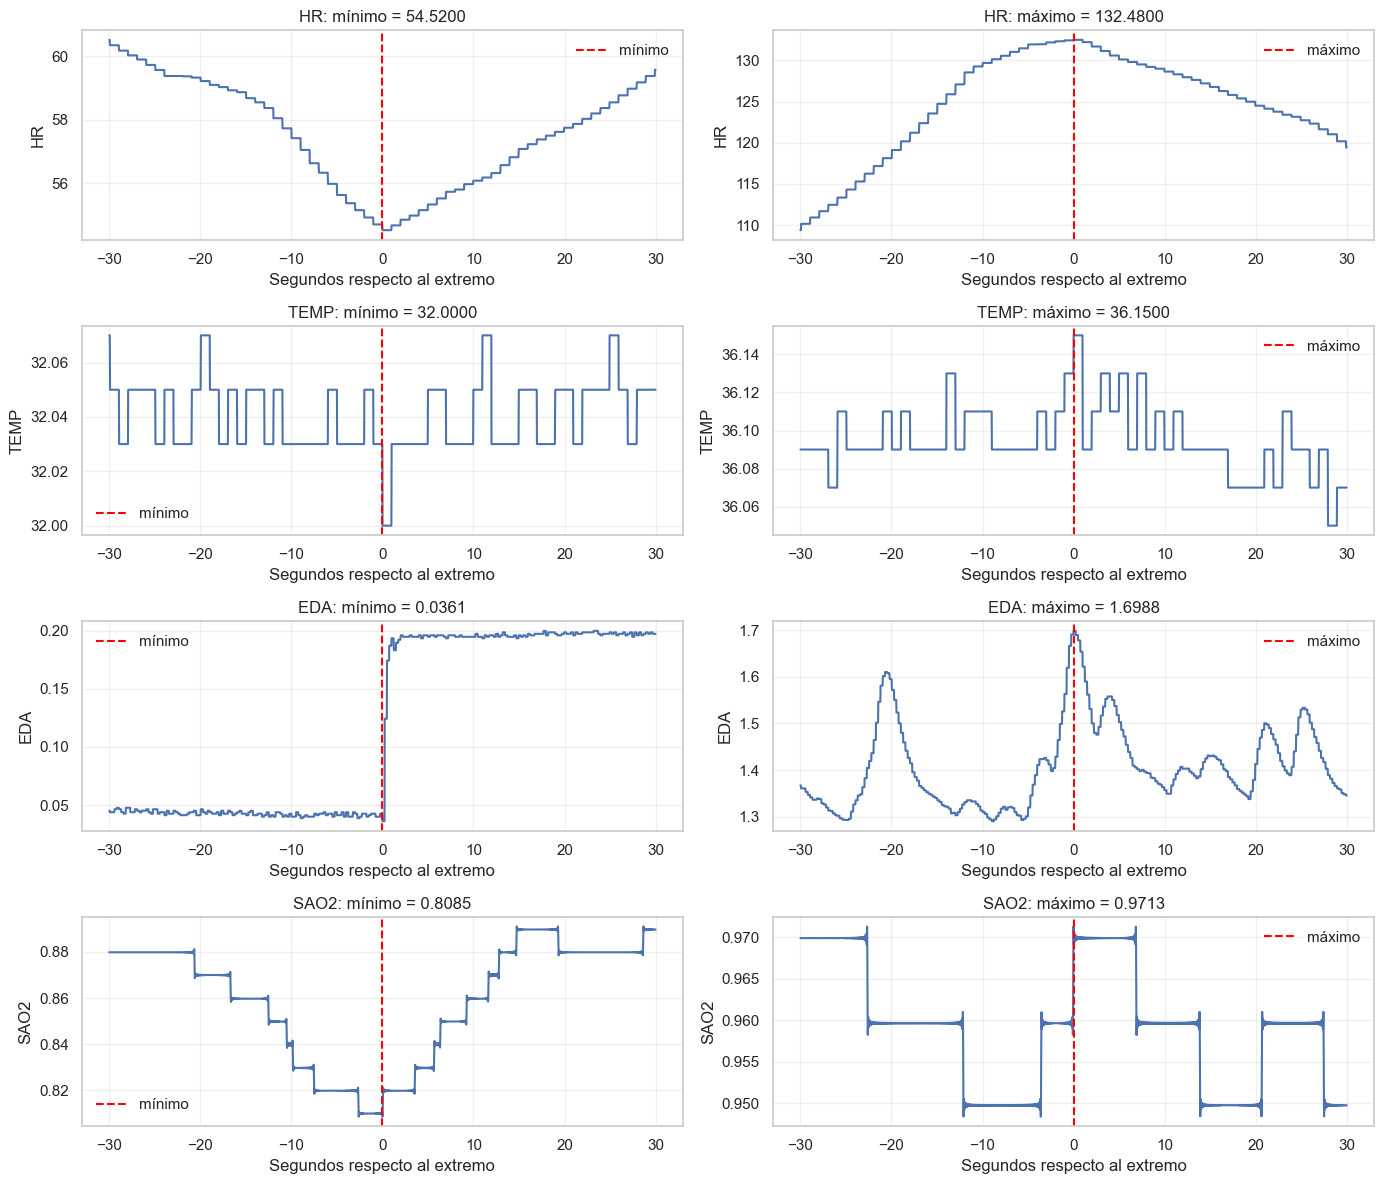


Los extremos y percentiles son descriptivos. No determinan automáticamente qué valores son errores. Cada gráfico tiene su propia escala vertical.


In [17]:
# 2.3.1. Distribución e inspección temporal de extremos

columnas_revision = ["HR", "TEMP", "EDA", "SAO2"]

# Serie numérica auxiliar; los datos originales se conservan.
valores_revision = (
    df_sample_eda[columnas_revision]
    .apply(pd.to_numeric, errors="coerce")
)

print("Paciente revisado:", extract_patient_id(sample_file))

print("\nDISTRIBUCIÓN DE LAS SEÑALES")
display(
    valores_revision
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

# Inspeccionar el mínimo y el máximo de cada señal.
# Cada gráfico puede corresponder a un momento distinto.
fig, axes = plt.subplots(
    len(columnas_revision), 2,
    figsize=(14, 3 * len(columnas_revision)),
    squeeze=False,
)

timestamps = pd.to_numeric(
    df_sample_eda["TIMESTAMP"], errors="coerce"
).reset_index(drop=True)

for fila, columna in enumerate(columnas_revision):
    valores = valores_revision[columna].reset_index(drop=True)
    finitos = valores.where(np.isfinite(valores))

    for j, extremo in enumerate(["mínimo", "máximo"]):
        ax = axes[fila, j]

        if finitos.notna().sum() == 0:
            ax.set_title(f"{columna}: sin valores finitos")
            ax.axis("off")
            continue

        # Si el extremo se repite, seleccionar su primera aparición.
        posicion = (
            finitos.idxmin()
            if extremo == "mínimo"
            else finitos.idxmax()
        )

        # Hasta 30 segundos antes y después, a 100 Hz.
        inicio = max(0, posicion - 3000)
        fin = min(len(valores), posicion + 3001)

        tiempo_relativo = (
            timestamps.iloc[inicio:fin] - timestamps.iloc[posicion]
        )

        ax.plot(
            tiempo_relativo,
            valores.iloc[inicio:fin].to_numpy(),
        )
        ax.axvline(
            0, color="red", linestyle="--", label=extremo
        )

        ax.set_title(
            f"{columna}: {extremo} = {valores.iloc[posicion]:.4f}"
        )
        ax.set_xlabel("Segundos respecto al extremo")
        ax.set_ylabel(columna)
        ax.grid(alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

print(
    "\nLos extremos y percentiles son descriptivos. "
    "No determinan automáticamente qué valores son errores. "
    "Cada gráfico tiene su propia escala vertical."
)

## 2.4 Preparación de epochs alineados del paciente muestra

In [18]:
# 2.4. Preparación de epochs alineados del paciente muestra

# Trabajar sobre una copia; conservar el registro original.
temp_df = df_sample_eda.reset_index(drop=True).copy()

# Validar continuidad e inferir alineación.
epoch_ids, completos, auditoria_muestra = definir_epochs(temp_df)

temp_df["epoch"] = epoch_ids

# Seleccionar únicamente ventanas completas de 3000 muestras.
temp_df = temp_df.loc[completos].copy()

# Verificar el tamaño de todas las ventanas seleccionadas.
muestras_por_epoch = temp_df.groupby("epoch").size()

if not muestras_por_epoch.eq(3000).all():
    raise ValueError("Hay epochs que no contienen 3000 muestras.")

# Comprobar que todas las filas originales estén contabilizadas.
filas_contabilizadas = (
    auditoria_muestra["filas_fragmento_inicial"]
    + auditoria_muestra["epochs_completos"] * 3000
    + auditoria_muestra["filas_fragmento_final"]
)

if filas_contabilizadas != len(df_sample_eda):
    raise ValueError("La auditoría no contabiliza todas las filas.")

print("Paciente:", extract_patient_id(sample_file))
print("\nAUDITORÍA TEMPORAL")
display(pd.DataFrame([auditoria_muestra]))

print("Filas seleccionadas:", len(temp_df))
print("Muestras por epoch: 3000")
print("Duración por epoch: 30 segundos")
print("Registro original conservado:", len(df_sample_eda), "filas")

# Preparar estadísticas exploratorias para la sección 2.5.
# En esta sección todavía no se calculan.
sensores_cols = ["HR", "TEMP", "EDA", "BVP", "SAO2"]

agg_dict = {
    col: ("std" if col == "BVP" else "mean")
    for col in sensores_cols
    if col in temp_df.columns
}

Paciente: 2

AUDITORÍA TEMPORAL


,filas_originales,desplazamiento,epochs_completos,filas_fragmento_inicial,filas_fragmento_final
0,1958400,2400,652,2400,0


Filas seleccionadas: 1956000
Muestras por epoch: 3000
Duración por epoch: 30 segundos
Registro original conservado: 1958400 filas


## 2.5 Variación y Evolución del Estado del Sueño a través de los Epochs

Paciente: 2
Epochs completos: 652
Epochs puros: 652
Epochs con varias etapas válidas: 0
Epochs con empate de moda: 0
Pureza mínima: 1.0

EPOCHS PARA REVISIÓN
Todas las ventanas contienen una única etapa válida.

TRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS


Etapa actual,W,N1,N2,N3,R
Etapa anterior,,,,,
W,102,31,26,0,14
N1,26,14,23,0,1
N2,29,19,284,0,2
N3,0,0,0,0,0
R,17,0,0,0,63


Pares contabilizados: 651


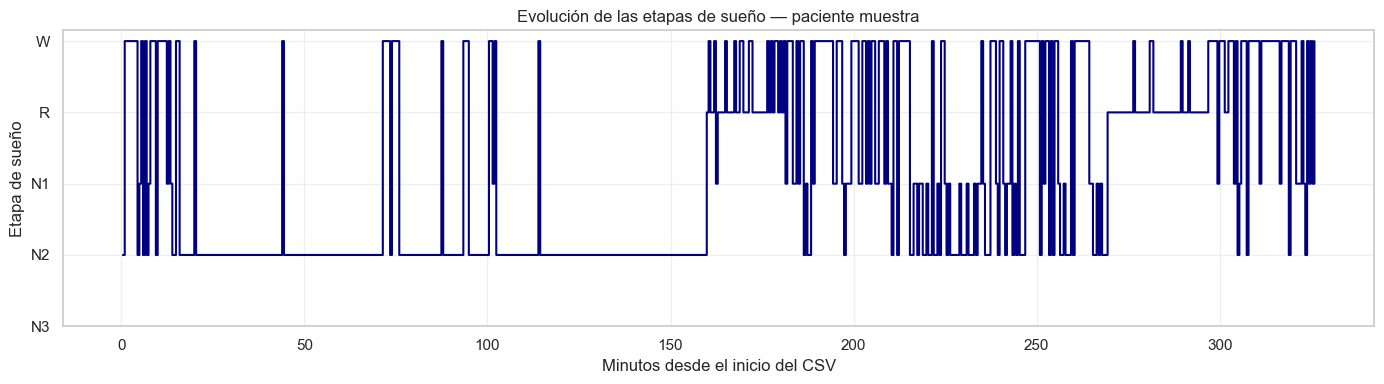

In [19]:
# 2.5. Evolución y transiciones del sueño

etapas_validas = ["W", "N1", "N2", "N3", "R"]


def process_epoch(group):
    res = {}

    res["tiempo_min"] = (
        group["TIMESTAMP"].iloc[0]
        - df_sample_eda["TIMESTAMP"].iloc[0]
    ) / 60

    etapas = group["Sleep_Stage"]
    etiquetas = etapas.where(etapas.isin(etapas_validas))
    modas = etiquetas.mode()

    res["stage_inicio"] = etapas.iloc[0]
    res["stage_fin"] = etapas.iloc[-1]

    # No elegir arbitrariamente una etapa cuando hay empate.
    res["empate_moda"] = len(modas) > 1
    res["stage_moda"] = (
        modas.iloc[0] if len(modas) == 1 else np.nan
    )

    res["etiquetas_nulas"] = int(etapas.isna().sum())
    res["etiquetas_invalidas"] = int(
        (etapas.notna() & ~etapas.isin(etapas_validas)).sum()
    )

    res["hubo_transicion_interna"] = (
        etiquetas.nunique(dropna=True) > 1
    )

    conteos = etiquetas.value_counts()
    res["porcentaje_pureza"] = (
        conteos.max() / len(group) if not conteos.empty else 0.0
    )

    # Estadísticas exploratorias configuradas en 2.4.
    for col, operacion in agg_dict.items():
        if operacion == "mean":
            res[f"{col}_mean"] = group[col].mean()
        elif operacion == "std":
            res[f"{col}_std"] = group[col].std()

    return pd.Series(res)


# Resumir cada ventana completa.
# La iteración explícita conserva la columna epoch en el grupo.
resultados = []

for epoch_id, group in temp_df.groupby("epoch", sort=True):
    resultado = process_epoch(group)
    resultado["epoch"] = epoch_id
    resultados.append(resultado)

df_sample_epochs = (
    pd.DataFrame(resultados)
    .sort_values("epoch")
    .reset_index(drop=True)
)

# Un epoch puro debe tener todas sus muestras en una etapa válida.
mascara_puros = df_sample_epochs["porcentaje_pureza"].eq(1.0)

print("Paciente:", extract_patient_id(sample_file))
print("Epochs completos:", len(df_sample_epochs))
print("Epochs puros:", int(mascara_puros.sum()))
print(
    "Epochs con varias etapas válidas:",
    int(df_sample_epochs["hubo_transicion_interna"].sum()),
)
print(
    "Epochs con empate de moda:",
    int(df_sample_epochs["empate_moda"].sum()),
)
print(
    "Pureza mínima:",
    df_sample_epochs["porcentaje_pureza"].min(),
)

# Mostrar cualquier ventana que necesite revisión.
epochs_revision = df_sample_epochs.loc[
    ~mascara_puros,
    [
        "epoch", "tiempo_min", "stage_inicio", "stage_fin",
        "stage_moda", "porcentaje_pureza", "empate_moda",
        "etiquetas_nulas", "etiquetas_invalidas",
    ],
]

print("\nEPOCHS PARA REVISIÓN")
if epochs_revision.empty:
    print("Todas las ventanas contienen una única etapa válida.")
else:
    display(epochs_revision)

# Relacionar cada epoch con el anterior, sin saltar ventanas.
df_sample_epochs["stage_moda_prev"] = (
    df_sample_epochs["stage_moda"].shift(1)
)

consecutivos = df_sample_epochs["epoch"].diff().eq(1)

# Usar únicamente pares de epochs consecutivos y puros.
pares_validos = (
    consecutivos
    & mascara_puros
    & mascara_puros.shift(1, fill_value=False)
)

transition_matrix = pd.crosstab(
    df_sample_epochs.loc[pares_validos, "stage_moda_prev"],
    df_sample_epochs.loc[pares_validos, "stage_moda"],
    rownames=["Etapa anterior"],
    colnames=["Etapa actual"],
).reindex(
    index=etapas_validas,
    columns=etapas_validas,
    fill_value=0,
)

print("\nTRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS")
display(transition_matrix)
print("Pares contabilizados:", int(pares_validos.sum()))

# Numeración utilizada únicamente para colocar etapas en el gráfico.
stage_mapping = {"W": 4, "R": 3, "N1": 2, "N2": 1, "N3": 0}
df_sample_epochs["stage_num"] = (
    df_sample_epochs["stage_moda"].map(stage_mapping)
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.step(
    df_sample_epochs["tiempo_min"],
    df_sample_epochs["stage_num"],
    where="post",
    color="navy",
)

# Marcar ventanas no puras que tengan una moda única.
revisables = (
    ~mascara_puros
    & df_sample_epochs["stage_num"].notna()
)

if revisables.any():
    ax.scatter(
        df_sample_epochs.loc[revisables, "tiempo_min"],
        df_sample_epochs.loc[revisables, "stage_num"],
        color="red",
        label="Epoch no puro",
        zorder=5,
    )
    ax.legend()

ax.set_yticks(
    list(stage_mapping.values()),
    labels=list(stage_mapping.keys()),
)
ax.set_xlabel("Minutos desde el inicio del CSV")
ax.set_ylabel("Etapa de sueño")
ax.set_title("Evolución de las etapas de sueño — paciente muestra")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2.6. Auditoría general de los pacientes disponibles

Se revisan todos los registros para detectar diferencias de estructura, problemas temporales, etiquetas inválidas y valores faltantes o no numéricos en las señales.

También se registran rangos, ceros en SAO2 y tramos exactamente constantes. Estos casos requieren interpretación: no se consideran errores automáticamente.

Los archivos se procesan por bloques y los resultados se guardan en CSV. No se modifican los datos originales.

In [20]:
# 2.6. Auditoría general por bloques

TAMANO_BLOQUE = 200_000

# Criterio exploratorio para listar tramos constantes.
# No es un umbral de limpieza ni demuestra un fallo del sensor.
SEGUNDOS_CONSTANTES_REVISION = 30

archivos_auditar = list(data_files)

if not archivos_auditar:
    raise ValueError("No hay archivos para auditar.")

nombres = [p.name for p in archivos_auditar]
if len(nombres) != len(set(nombres)):
    raise ValueError(
        "Hay nombres de archivo duplicados. Revisar data_files."
    )

print("Archivos encontrados:", len(archivos_auditar))

# S002 se utiliza únicamente como referencia de columnas.
referencia = next(
    (p for p in archivos_auditar if p.name == "S002_PSG_df.csv"),
    archivos_auditar[0],
)
columnas_referencia = pd.read_csv(referencia, nrows=0).columns.tolist()

excluidas = {
    "TIMESTAMP", "Sleep_Stage", "patient_id",
    "Obstructive_Apnea", "Central_Apnea",
    "Hypopnea", "Multiple_Events",
}
senales_referencia = [
    c for c in columnas_referencia if c not in excluidas
]
etapas_validas = ["W", "N1", "N2", "N3", "R"]


def nuevo_tramo():
    return {
        "cola": 0,
        "mayor": 0,
        "inicio": None,
    }


def actualizar_tramo(mascara, estado, fila_inicio):
    """Mayor tramo True, incluyendo continuidad entre bloques."""
    mascara = np.asarray(mascara, dtype=bool)

    if len(mascara) == 0:
        return

    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    if len(inicios) == 0:
        estado["cola"] = 0
        return

    largos = finales - inicios
    posiciones = fila_inicio + inicios

    if inicios[0] == 0:
        largos[0] += estado["cola"]
        posiciones[0] -= estado["cola"]

    mayor = int(np.argmax(largos))

    if largos[mayor] > estado["mayor"]:
        estado["mayor"] = int(largos[mayor])
        estado["inicio"] = int(posiciones[mayor])

    estado["cola"] = (
        int(largos[-1]) if mascara[-1] else 0
    )


resultados_pacientes = []
resultados_senales = []
casos_revision = []

for numero, ruta in enumerate(archivos_auditar, start=1):
    print(
        f"[{numero}/{len(archivos_auditar)}] {ruta.name}",
        flush=True,
    )

    try:
        columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
        columnas_faltantes = sorted(
            set(columnas_referencia) - set(columnas)
        )
        columnas_adicionales = sorted(
            set(columnas) - set(columnas_referencia)
        )

        requeridas = {"TIMESTAMP", "Sleep_Stage"}
        if not requeridas.issubset(columnas):
            raise ValueError("Falta TIMESTAMP o Sleep_Stage.")

        senales = [
            c for c in senales_referencia if c in columnas
        ]

        controles = {
            c: {
                "nulos": 0,
                "no_numericos": 0,
                "infinitos": 0,
                "minimo": np.inf,
                "maximo": -np.inf,
                "tipos": set(),
                "anterior": np.nan,
                "constante": nuevo_tramo(),
            }
            for c in senales
        }

        filas = 0
        timestamp_anterior = None
        etapa_anterior = None
        timestamp_inicio = None
        timestamp_final = None

        timestamps_invalidos = 0
        intervalos_irregulares = 0
        intervalos_no_crecientes = 0

        etiquetas_nulas = 0
        etiquetas_invalidas = 0
        valores_invalidos = set()
        conteos_etapas = {e: 0 for e in etapas_validas}

        restos = set()
        cambios_etapa = 0
        ceros_sao2 = 0
        sao2_fuera_0_1 = 0
        tramo_ceros = nuevo_tramo()

        columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales

        with pd.read_csv(
            ruta,
            usecols=columnas_leer,
            chunksize=TAMANO_BLOQUE,
            low_memory=False,
        ) as lector:

            for bloque in lector:
                fila_inicio = filas
                cantidad = len(bloque)

                # 1. Tiempo: incluir el límite entre bloques.
                t = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy(dtype=float)

                if timestamp_inicio is None:
                    timestamp_inicio = t[0]
                timestamp_final = t[-1]

                timestamps_invalidos += int(
                    (~np.isfinite(t)).sum()
                )

                tiempos_comparar = (
                    np.r_[timestamp_anterior, t]
                    if timestamp_anterior is not None
                    else t
                )

                diferencias = np.diff(tiempos_comparar)
                pares_finitos = (
                    np.isfinite(tiempos_comparar[:-1])
                    & np.isfinite(tiempos_comparar[1:])
                )

                intervalos_irregulares += int(
                    (
                        pares_finitos
                        & ~np.isclose(
                            diferencias, 0.01,
                            atol=1e-6, rtol=0,
                        )
                    ).sum()
                )
                intervalos_no_crecientes += int(
                    (pares_finitos & (diferencias <= 0)).sum()
                )
                timestamp_anterior = t[-1]

                # 2. Etiquetas y alineación.
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = etapa_anterior

                invalidas = (
                    etapas.notna()
                    & ~etapas.isin(etapas_validas)
                )

                etiquetas_nulas += int(etapas.isna().sum())
                etiquetas_invalidas += int(invalidas.sum())
                valores_invalidos.update(
                    etapas.loc[invalidas].astype(str).unique()
                )

                conteos = etapas.value_counts()
                for etapa in etapas_validas:
                    conteos_etapas[etapa] += int(
                        conteos.get(etapa, 0)
                    )

                cambios = (
                    etapas.isin(etapas_validas)
                    & anteriores.isin(etapas_validas)
                    & etapas.ne(anteriores)
                )

                posiciones = (
                    np.flatnonzero(cambios.to_numpy())
                    + fila_inicio
                )

                cambios_etapa += len(posiciones)
                restos.update((posiciones % 3000).tolist())
                etapa_anterior = etapas.iloc[-1]

                # 3. Calidad y rangos de cada señal.
                for col in senales:
                    control = controles[col]
                    original = bloque[col]
                    control["tipos"].add(str(original.dtype))

                    numerico = pd.to_numeric(
                        original, errors="coerce"
                    )
                    valores = numerico.to_numpy(dtype=float)
                    finitos = np.isfinite(valores)

                    control["nulos"] += int(original.isna().sum())
                    control["no_numericos"] += int(
                        (original.notna() & numerico.isna()).sum()
                    )
                    control["infinitos"] += int(
                        np.isinf(valores).sum()
                    )

                    if finitos.any():
                        control["minimo"] = min(
                            control["minimo"],
                            float(valores[finitos].min()),
                        )
                        control["maximo"] = max(
                            control["maximo"],
                            float(valores[finitos].max()),
                        )

                    # Igualdad exacta con la muestra anterior.
                    anteriores_valores = np.r_[
                        control["anterior"], valores[:-1]
                    ]
                    iguales = (
                        finitos
                        & np.isfinite(anteriores_valores)
                        & (valores == anteriores_valores)
                    )

                    actualizar_tramo(
                        iguales, control["constante"], fila_inicio
                    )
                    control["anterior"] = valores[-1]

                    if col == "SAO2":
                        ceros = finitos & (valores == 0)
                        ceros_sao2 += int(ceros.sum())

                        sao2_fuera_0_1 += int(
                            (
                                finitos
                                & ((valores < 0) | (valores > 1))
                            ).sum()
                        )

                        actualizar_tramo(
                            ceros, tramo_ceros, fila_inicio
                        )

                filas += cantidad

        # 4. Determinar si puede inferirse una alineación.
        continuo = (
            timestamps_invalidos == 0
            and intervalos_irregulares == 0
            and filas > 0
        )

        desplazamiento = np.nan
        epochs_completos = np.nan
        fragmento_inicial = np.nan
        fragmento_final = np.nan

        if not continuo:
            estado_alineacion = "Revisar tiempo"
        elif len(restos) == 0:
            estado_alineacion = "Sin cambios: no determinada"
        elif len(restos) > 1:
            estado_alineacion = "Desplazamientos inconsistentes"
        else:
            estado_alineacion = "Alineación candidata consistente"
            desplazamiento = int(next(iter(restos)))
            epochs_completos = (filas - desplazamiento) // 3000
            fragmento_inicial = desplazamiento
            fragmento_final = (filas - desplazamiento) % 3000

        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Completa",
            "filas": filas,
            "columnas_csv": len(columnas),
            "columnas_faltantes": columnas_faltantes,
            "columnas_adicionales": columnas_adicionales,
            "timestamp_inicio": timestamp_inicio,
            "timestamp_final": timestamp_final,
            "timestamps_invalidos": timestamps_invalidos,
            "intervalos_irregulares": intervalos_irregulares,
            "intervalos_no_crecientes": intervalos_no_crecientes,
            "etiquetas_nulas": etiquetas_nulas,
            "etiquetas_invalidas": etiquetas_invalidas,
            "valores_invalidos": sorted(valores_invalidos),
            "cambios_etapa": cambios_etapa,
            "restos_3000": sorted(restos),
            "estado_alineacion": estado_alineacion,
            "desplazamiento": desplazamiento,
            "epochs_completos": epochs_completos,
            "fragmento_inicial": fragmento_inicial,
            "fragmento_final": fragmento_final,
            "ceros_sao2": ceros_sao2,
            # Revisar escala antes de considerar estos valores errores.
            "sao2_fuera_escala_0_1": sao2_fuera_0_1,
            **{f"muestras_{e}": conteos_etapas[e]
               for e in etapas_validas},
        })

        for col, control in controles.items():
            tramo = control["constante"]

            # N igualdades consecutivas representan N+1 muestras.
            muestras_constantes = (
                tramo["mayor"] + 1 if tramo["mayor"] else 0
            )
            inicio_constante = (
                tramo["inicio"] - 1
                if tramo["mayor"] else None
            )
            duracion_constante = (
                tramo["mayor"] / 100
            )

            resultados_senales.append({
                "archivo": ruta.name,
                "señal": col,
                "filas": filas,
                "tipos_observados": " / ".join(
                    sorted(control["tipos"])
                ),
                "nulos": control["nulos"],
                "no_numericos": control["no_numericos"],
                "infinitos": control["infinitos"],
                "minimo": (
                    control["minimo"]
                    if np.isfinite(control["minimo"]) else np.nan
                ),
                "maximo": (
                    control["maximo"]
                    if np.isfinite(control["maximo"]) else np.nan
                ),
                "mayor_tramo_constante_muestras": muestras_constantes,
                "inicio_tramo_constante_fila": inicio_constante,
                "duracion_constante_segundos_100hz":
                    duracion_constante,
            })

            if duracion_constante >= SEGUNDOS_CONSTANTES_REVISION:
                casos_revision.append({
                    "archivo": ruta.name,
                    "señal": col,
                    "motivo": "Mayor tramo exactamente constante",
                    "fila_inicio": inicio_constante,
                    "muestras": muestras_constantes,
                    "duracion_equivalente_segundos":
                        muestras_constantes / 100,
                })

        if tramo_ceros["mayor"] > 0:
            casos_revision.append({
                "archivo": ruta.name,
                "señal": "SAO2",
                "motivo": "Mayor tramo de ceros",
                "fila_inicio": tramo_ceros["inicio"],
                "muestras": tramo_ceros["mayor"],
                "duracion_equivalente_segundos":
                    tramo_ceros["mayor"] / 100,
            })

    except Exception as error:
        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Error",
            "error": str(error),
        })
        print("Error registrado:", error, flush=True)

    # Guardar avance después de cada paciente.
    carpeta_salida = Path("/kaggle/working/auditoria")
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(resultados_pacientes).to_csv(
        carpeta_salida / "auditoria_pacientes.csv", index=False
    )
    pd.DataFrame(resultados_senales).to_csv(
        carpeta_salida / "auditoria_senales.csv", index=False
    )
    pd.DataFrame(
        casos_revision,
        columns=[
            "archivo", "señal", "motivo", "fila_inicio",
            "muestras", "duracion_equivalente_segundos",
        ],
    ).to_csv(
        carpeta_salida / "casos_revision.csv", index=False
    )

# Tablas disponibles para el análisis posterior.
auditoria_pacientes = pd.DataFrame(resultados_pacientes)
auditoria_senales = pd.DataFrame(resultados_senales)
casos_revision = pd.DataFrame(casos_revision)

print("\nAUDITORÍA FINALIZADA")
print("Archivos registrados:", len(auditoria_pacientes))
print(
    "Lecturas completas:",
    auditoria_pacientes["estado_lectura"].eq("Completa").sum(),
)
print(
    "Errores de lectura:",
    auditoria_pacientes["estado_lectura"].eq("Error").sum(),
)

if "estado_alineacion" in auditoria_pacientes:
    print("\nESTADOS DE ALINEACIÓN")
    print(
        auditoria_pacientes["estado_alineacion"]
        .value_counts()
        .to_string()
    )

if not auditoria_senales.empty:
    print("\nCELDAS AFECTADAS EN SEÑALES")
    print(
        auditoria_senales[
            ["nulos", "no_numericos", "infinitos"]
        ].sum().to_string()
    )

print("\nCasos registrados para revisión:", len(casos_revision))
print("Resultados guardados en:", carpeta_salida)

Archivos encontrados: 18
[1/18] S002_PSG_df.csv
[2/18] S003_PSG_df.csv
[3/18] S004_PSG_df.csv
[4/18] S005_PSG_df.csv
[5/18] S006_PSG_df.csv
[6/18] S007_PSG_df.csv
[7/18] S008_PSG_df.csv
[8/18] S009_PSG_df.csv
[9/18] S010_PSG_df.csv
[10/18] S016_PSG_df.csv
[11/18] S017_PSG_df.csv
[12/18] S019_PSG_df.csv
[13/18] S082_PSG_df.csv
[14/18] S083_PSG_df.csv
[15/18] S084_PSG_df.csv
[16/18] S086_PSG_df.csv
[17/18] S087_PSG_df.csv
[18/18] S088_PSG_df.csv

AUDITORÍA FINALIZADA
Archivos registrados: 18
Lecturas completas: 18
Errores de lectura: 0

ESTADOS DE ALINEACIÓN
estado_alineacion
Alineación candidata consistente    18

CELDAS AFECTADAS EN SEÑALES
nulos           0
no_numericos    0
infinitos       0

Casos registrados para revisión: 153
Resultados guardados en: \kaggle\working\auditoria


### 2.6.1. Revisión de alineación y etiquetas faltantes

Se localizan los cambios de etapa de S027 y S048 para investigar
sus desplazamientos inconsistentes.

También se identifican los tramos con etiquetas inválidas en
S027, S089, S095 y S096. La etiqueta `Missing` representa un
valor presente en el archivo, pero no una etapa válida del modelo.

No se eliminan filas ni se asignan desplazamientos automáticamente.
El objetivo es reunir evidencia antes de definir el tratamiento.

In [21]:
# 2.6.1. Inspección de alineación y etiquetas

pacientes_revision_preferidos = [
    "S027_PSG_df.csv",
    "S048_PSG_df.csv",
    "S089_PSG_df.csv",
    "S095_PSG_df.csv",
    "S096_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_etiquetas = [
    nombre for nombre in pacientes_revision_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_etiquetas:
    nombres_revision_etiquetas = [p.name for p in data_files[:2]]
    print("Casos históricos ausentes; se inspeccionan ejemplos disponibles.")

etapas_validas = ["W", "N1", "N2", "N3", "R"]
cambios_revision = []
tramos_etiquetas_revision = []


def registrar_tramos_invalidos(
    mascara, tiempos, fila_inicio, archivo, resultados
):
    """Registrar tramos contiguos, uniendo límites entre bloques."""
    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    for inicio, fin in zip(inicios, finales):
        fila_desde = int(fila_inicio + inicio)
        fila_hasta = int(fila_inicio + fin - 1)

        if (
            resultados
            and resultados[-1]["archivo"] == archivo
            and resultados[-1]["fila_final"] + 1 == fila_desde
        ):
            resultados[-1]["fila_final"] = fila_hasta
            resultados[-1]["timestamp_final"] = float(tiempos[fin - 1])
        else:
            resultados.append({
                "archivo": archivo,
                "fila_inicio": fila_desde,
                "fila_final": fila_hasta,
                "timestamp_inicio": float(tiempos[inicio]),
                "timestamp_final": float(tiempos[fin - 1]),
            })


for nombre in nombres_revision_etiquetas:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando: {nombre}", flush=True)

    fila_inicio = 0
    ultima_etapa = None

    with pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "Sleep_Stage"],
        chunksize=200_000,
    ) as lector:
        for bloque in lector:
            etapas = bloque["Sleep_Stage"].reset_index(drop=True)
            tiempos = pd.to_numeric(
                bloque["TIMESTAMP"], errors="coerce"
            ).to_numpy()

            anteriores = etapas.shift()
            if fila_inicio > 0:
                anteriores.iloc[0] = ultima_etapa

            # Registrar todo cambio, incluyendo entrada/salida de Missing.
            cambios = etapas.ne(anteriores).fillna(False)
            if fila_inicio == 0:
                cambios.iloc[0] = False

            posiciones = np.flatnonzero(cambios.to_numpy())

            for posicion in posiciones:
                anterior = anteriores.iloc[posicion]
                actual = etapas.iloc[posicion]
                fila_original = fila_inicio + int(posicion)

                entre_validas = (
                    anterior in etapas_validas
                    and actual in etapas_validas
                )

                cambios_revision.append({
                    "archivo": nombre,
                    "fila_original": fila_original,
                    "TIMESTAMP": tiempos[posicion],
                    "etapa_anterior": anterior,
                    "etapa_actual": actual,
                    "entre_etapas_validas": entre_validas,
                    "resto_3000": fila_original % 3000,
                })

            invalidas = ~etapas.isin(etapas_validas)
            registrar_tramos_invalidos(
                invalidas.to_numpy(),
                tiempos,
                fila_inicio,
                nombre,
                tramos_etiquetas_revision,
            )

            ultima_etapa = etapas.iloc[-1]
            fila_inicio += len(bloque)

cambios_revision = pd.DataFrame(
    cambios_revision,
    columns=[
        "archivo", "fila_original", "TIMESTAMP", "etapa_anterior",
        "etapa_actual", "entre_etapas_validas", "resto_3000",
    ],
)
tramos_etiquetas_revision = pd.DataFrame(
    tramos_etiquetas_revision,
    columns=[
        "archivo", "fila_inicio", "fila_final",
        "timestamp_inicio", "timestamp_final",
    ],
)

if not tramos_etiquetas_revision.empty:
    tramos_etiquetas_revision["muestras"] = (
        tramos_etiquetas_revision["fila_final"]
        - tramos_etiquetas_revision["fila_inicio"]
        + 1
    )
    tramos_etiquetas_revision["duracion_segundos_100hz"] = (
        tramos_etiquetas_revision["muestras"] / 100
    )

print("\nCAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO")
resumen_desplazamientos = (
    cambios_revision.loc[
        cambios_revision["entre_etapas_validas"]
    ]
    .groupby(["archivo", "resto_3000"])
    .agg(
        cambios=("fila_original", "size"),
        primera_fila=("fila_original", "min"),
        ultima_fila=("fila_original", "max"),
    )
    .reset_index()
)
display(resumen_desplazamientos)

print("\nTRAMOS CON ETIQUETAS NO VÁLIDAS")
if tramos_etiquetas_revision.empty:
    print("No se encontraron.")
else:
    display(tramos_etiquetas_revision)

# Mostrar evidencia de S027/S048 sin imprimir todos sus cambios.
for nombre in ["S027_PSG_df.csv", "S048_PSG_df.csv"]:
    if nombre not in nombres_revision_etiquetas:
        continue

    tabla = cambios_revision.loc[
        cambios_revision["archivo"].eq(nombre)
    ].copy()

    tabla["resto_anterior"] = tabla["resto_3000"].shift(1)

    # Cambios de resto y entradas/salidas de etiquetas inválidas.
    relevantes = (
        tabla["resto_3000"].ne(tabla["resto_anterior"])
        | ~tabla["entre_etapas_validas"]
    )

    # Incluir un cambio anterior y posterior como contexto.
    contexto = (
        relevantes
        | relevantes.shift(1, fill_value=False)
        | relevantes.shift(-1, fill_value=False)
    )

    print(f"\nCAMBIOS PARA INSPECCIÓN: {nombre}")
    display(tabla.loc[contexto].drop(columns="resto_anterior"))

carpeta_revision = Path("/kaggle/working/auditoria")
carpeta_revision.mkdir(parents=True, exist_ok=True)

cambios_revision.to_csv(
    carpeta_revision / "revision_cambios_etapas.csv",
    index=False,
)
tramos_etiquetas_revision.to_csv(
    carpeta_revision / "revision_tramos_etiquetas.csv",
    index=False,
)

print("\nNo se modificaron etiquetas ni posiciones.")

Casos históricos ausentes; se inspeccionan ejemplos disponibles.
Revisando: S002_PSG_df.csv
Revisando: S003_PSG_df.csv

CAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO


,archivo,resto_3000,cambios,primera_fila,ultima_fila
0,S002_PSG_df.csv,2400,189,2400,1955400
1,S003_PSG_df.csv,2400,73,2400,2318400



TRAMOS CON ETIQUETAS NO VÁLIDAS
No se encontraron.

No se modificaron etiquetas ni posiciones.


### 2.6.2. Revisión de rangos y comportamiento de SAO2

La auditoría encontró muestras fuera del intervalo 0–1 en 56
pacientes y valores alrededor de 12 en S027.

Se resume la evidencia general y se inspeccionan S004, S006 y
S027: los dos primeros presentaron epochs con medias cercanas a
cero; el tercero presenta un rango diferente.

Se revisan mínimos, máximos y cambios entre muestras consecutivas.
Estar fuera del intervalo supuesto requiere comprobar escala y
procesamiento; no determina por sí solo qué corrección aplicar.
Los valores originales se conservan.

RESUMEN GENERAL DE SAO2
Pacientes con muestras fuera de 0–1: 15
Pacientes con ceros exactos: 0

DIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1


,archivo,filas,ceros_sao2,sao2_fuera_escala_0_1,minimo,maximo,fuera_0_1_pct
10,S017_PSG_df.csv,2311500,0,6265,-0.13635,1.13613,0.27104
8,S010_PSG_df.csv,2385100,0,6027,-0.14662,1.12484,0.25269
11,S019_PSG_df.csv,2074200,0,4290,-0.13228,1.10243,0.20683
17,S088_PSG_df.csv,2141200,0,4320,-0.12408,1.03417,0.20176
15,S086_PSG_df.csv,2302500,0,4582,-0.13231,1.10240,0.19900
7,S009_PSG_df.csv,2298400,0,2767,-0.13640,1.13608,0.12039
13,S083_PSG_df.csv,2193000,0,2593,-0.13239,1.10232,0.11824
4,S006_PSG_df.csv,2403000,0,2506,-0.13504,1.12485,0.10429
3,S005_PSG_df.csv,2191300,0,1894,-0.13362,1.11368,0.08643
5,S007_PSG_df.csv,2391000,0,2057,-0.12956,1.07950,0.08603



Inspeccionando SAO2: S004_PSG_df.csv


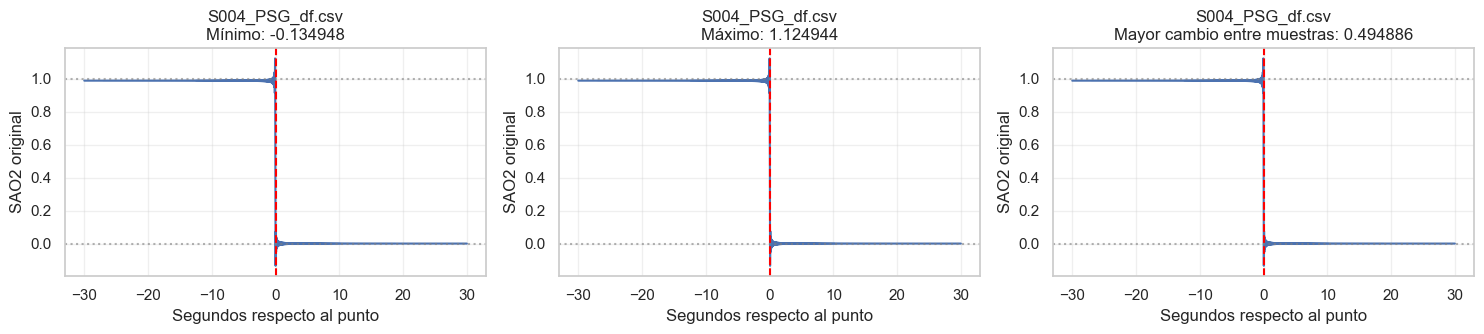


Inspeccionando SAO2: S006_PSG_df.csv


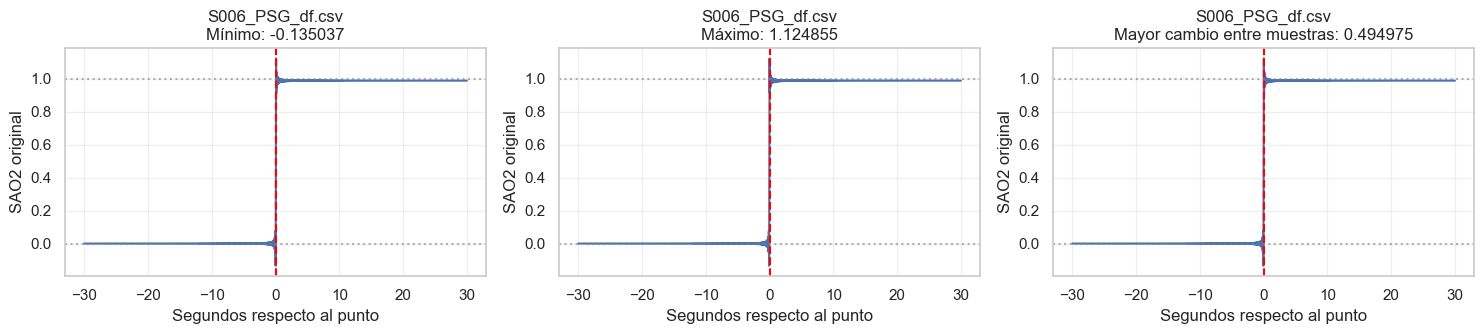


ESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS


,count,mean,std,min,1%,50%,99%,max,archivo,negativos,mayores_1,ceros_exactos
0,2413100.0,0.893009,0.079369,-0.134948,0.740000,0.899768,0.980061,1.124944,S004_PSG_df.csv,1458,19,0
1,2403000.0,0.961867,0.094311,-0.135037,0.919763,0.969924,0.989707,1.124855,S006_PSG_df.csv,2470,36,0



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,SAO2,SAO2_anterior
0,S004_PSG_df.csv,Mínimo,238270,9222.70,-0.134948,-0.118288
1,S004_PSG_df.csv,Máximo,238262,9222.62,1.124944,1.069550
2,S004_PSG_df.csv,Mayor cambio entre muestras,238266,9222.66,0.494886,0.772511
3,S006_PSG_df.csv,Mínimo,2006222,27262.22,-0.135037,-0.079650
4,S006_PSG_df.csv,Máximo,2006230,27262.30,1.124855,1.108188
5,S006_PSG_df.csv,Mayor cambio entre muestras,2006226,27262.26,0.494975,0.217356



No se modificaron valores. Los gráficos tienen escalas verticales independientes. Falta contrastar los casos con el procesamiento de origen.


In [22]:
# 2.6.2. Inspección de SAO2

carpeta_revision = Path("/kaggle/working/auditoria")

# Utilizar la auditoría guardada; no recorrer nuevamente todos los CSV.
auditoria_p = pd.read_csv(
    carpeta_revision / "auditoria_pacientes.csv"
)
auditoria_s = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_sao2 = auditoria_s.loc[
    auditoria_s["señal"].eq("SAO2"),
    ["archivo", "minimo", "maximo"],
]

resumen_sao2 = auditoria_p[
    ["archivo", "filas", "ceros_sao2", "sao2_fuera_escala_0_1"]
].merge(rangos_sao2, on="archivo", how="left")

resumen_sao2["fuera_0_1_pct"] = (
    100 * resumen_sao2["sao2_fuera_escala_0_1"]
    / resumen_sao2["filas"]
)

print("RESUMEN GENERAL DE SAO2")
print(
    "Pacientes con muestras fuera de 0–1:",
    int(resumen_sao2["sao2_fuera_escala_0_1"].gt(0).sum()),
)
print(
    "Pacientes con ceros exactos:",
    int(resumen_sao2["ceros_sao2"].gt(0).sum()),
)

# Mostrar los rangos más alejados del intervalo supuesto.
print("\nDIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1")
display(
    resumen_sao2.sort_values(
        "fuera_0_1_pct", ascending=False
    ).head(10).round(5)
)

pacientes_sao2_preferidos = [
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
    "S027_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_sao2 = [
    nombre for nombre in pacientes_sao2_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_sao2:
    nombres_revision_sao2 = [p.name for p in data_files[:3]]

estadisticas_sao2 = []
puntos_revision_sao2 = []

for nombre in nombres_revision_sao2:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando SAO2: {nombre}", flush=True)

    # Solo dos columnas; un paciente por vez.
    datos = pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "SAO2"],
    )

    valores = pd.to_numeric(datos["SAO2"], errors="coerce")
    tiempos = pd.to_numeric(datos["TIMESTAMP"], errors="coerce")
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        continue

    estadisticas = finitos.describe(
        percentiles=[0.01, 0.50, 0.99]
    ).to_dict()
    estadisticas["archivo"] = nombre
    estadisticas["negativos"] = int(finitos.lt(0).sum())
    estadisticas["mayores_1"] = int(finitos.gt(1).sum())
    estadisticas["ceros_exactos"] = int(finitos.eq(0).sum())
    estadisticas_sao2.append(estadisticas)

    # Diferencia absoluta entre muestras consecutivas.
    diferencias = finitos.diff().abs()

    posiciones = {
        "Mínimo": int(finitos.idxmin()),
        "Máximo": int(finitos.idxmax()),
    }

    if diferencias.notna().any():
        posiciones["Mayor cambio entre muestras"] = int(
            diferencias.idxmax()
        )

    fig, axes = plt.subplots(
        1, len(posiciones),
        figsize=(5 * len(posiciones), 3.5),
        squeeze=False,
    )

    for ax, (motivo, posicion) in zip(
        axes[0], posiciones.items()
    ):
        inicio = max(0, posicion - 3000)
        fin = min(len(datos), posicion + 3001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")

        # Referencias de escala; no son reglas de limpieza.
        ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
        ax.axhline(1, color="gray", linestyle=":", alpha=0.6)

        ax.set_title(
            f"{nombre}\n{motivo}: {valores.iloc[posicion]:.6f}"
        )
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("SAO2 original")
        ax.grid(alpha=0.3)

        puntos_revision_sao2.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "SAO2": valores.iloc[posicion],
            "SAO2_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
        })

    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos, diferencias

estadisticas_sao2 = pd.DataFrame(estadisticas_sao2)
puntos_revision_sao2 = pd.DataFrame(puntos_revision_sao2)

print("\nESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS")
display(estadisticas_sao2.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_sao2)

estadisticas_sao2.to_csv(
    carpeta_revision / "revision_estadisticas_sao2.csv",
    index=False,
)
puntos_revision_sao2.to_csv(
    carpeta_revision / "revision_puntos_sao2.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "Los gráficos tienen escalas verticales independientes. "
    "Falta contrastar los casos con el procesamiento de origen."
)

### 2.6.3. Revisión de señales constantes

Se identifican señales constantes durante todo el registro y tramos
prolongados sin cambios, utilizando los resultados de la auditoría general.

Se priorizan S097 y los pacientes con IBI constante. Una señal
numérica y sin nulos puede igualmente carecer de variación útil.

Los tramos constantes no se consideran errores automáticamente:
pueden relacionarse con el registro, el relleno o el procesamiento.
No se modifican ni eliminan señales en esta revisión.

In [23]:
# 2.6.3. Revisión de señales constantes

carpeta_revision = Path("/kaggle/working/auditoria")
auditoria_constantes = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

columnas_detalle = [
    "archivo",
    "señal",
    "filas",
    "minimo",
    "maximo",
    "mayor_tramo_constante_muestras",
    "inicio_tramo_constante_fila",
    "duracion_constante_segundos_100hz",
]

# Porcentaje del registro ocupado por su mayor tramo constante.
auditoria_constantes["mayor_tramo_constante_pct"] = (
    100
    * auditoria_constantes["mayor_tramo_constante_muestras"]
    / auditoria_constantes["filas"]
)

# Constancia en todas las muestras del registro.
constantes_completas = auditoria_constantes.loc[
    auditoria_constantes["mayor_tramo_constante_muestras"].eq(
        auditoria_constantes["filas"]
    )
    & auditoria_constantes["filas"].gt(0)
].copy()

print("SEÑALES CONSTANTES DURANTE TODO EL REGISTRO")
display(
    constantes_completas[
        columnas_detalle + ["mayor_tramo_constante_pct"]
    ].sort_values(["archivo", "señal"])
)

print("\nCANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE")
display(
    constantes_completas.groupby("archivo")
    .size()
    .rename("señales_constantes")
    .reset_index()
)

print("\nDETALLE DE S097")
display(
    auditoria_constantes.loc[
        auditoria_constantes["archivo"].eq("S097_PSG_df.csv"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ].sort_values("señal")
)

print("\nIBI: DIEZ MAYORES TRAMOS CONSTANTES")
display(
    auditoria_constantes.loc[
        auditoria_constantes["señal"].eq("IBI"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ]
    .sort_values("mayor_tramo_constante_pct", ascending=False)
    .head(10)
)

# Umbral exploratorio, no una regla de eliminación.
tramos_prolongados = auditoria_constantes.loc[
    auditoria_constantes[
        "duracion_constante_segundos_100hz"
    ].ge(30)
].copy()

print("\nTRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS")
display(
    tramos_prolongados.groupby("señal")
    .agg(
        pacientes=("archivo", "nunique"),
        mayor_duracion_segundos=(
            "duracion_constante_segundos_100hz", "max"
        ),
    )
    .reset_index()
    .sort_values("pacientes", ascending=False)
)

constantes_completas.to_csv(
    carpeta_revision / "revision_constantes_completas.csv",
    index=False,
)

print(
    "\nNo se modificaron señales. "
    "Una señal completamente constante tendrá desviación estándar "
    "cero en sus epochs, pero eso no explica la causa. "
    "La duración supone continuidad a 100 Hz, "
    "comprobada en la auditoría general."
)

SEÑALES CONSTANTES DURANTE TODO EL REGISTRO


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct



CANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE


,archivo,señales_constantes



DETALLE DE S097


...


IBI: DIEZ MAYORES TRAMOS CONSTANTES


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
285,S017_PSG_df.csv,IBI,2311500,1.031250,1.546875,2272963,38537.0,22729.62,98.332814
415,S086_PSG_df.csv,IBI,2302500,0.390625,1.625000,859552,1442948.0,8595.51,37.331249
25,S002_PSG_df.csv,IBI,1958400,0.531250,1.406250,521017,1437383.0,5210.16,26.604218
363,S083_PSG_df.csv,IBI,2193000,0.375000,1.562500,176074,2016926.0,1760.73,8.028910
311,S019_PSG_df.csv,IBI,2074200,0.515625,1.531250,124935,1949265.0,1249.34,6.023286
181,S008_PSG_df.csv,IBI,2231500,0.437500,1.546875,34829,1790892.0,348.28,1.560789
259,S016_PSG_df.csv,IBI,2250400,0.406250,1.484375,30377,741558.0,303.76,1.349849
155,S007_PSG_df.csv,IBI,2391000,0.359375,1.218750,30040,876712.0,300.39,1.256378
103,S005_PSG_df.csv,IBI,2191300,0.593750,1.218750,24596,478152.0,245.95,1.122439
337,S082_PSG_df.csv,IBI,1980700,0.546875,1.703125,20383,50938.0,203.82,1.029081



TRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS


,señal,pacientes,mayor_duracion_segundos
1,ACC_X,18,672.45
3,ACC_Z,18,402.71
2,ACC_Y,18,1065.00
16,IBI,18,22729.62
4,BVP,16,53.71
23,TEMP,16,61.67
15,HR,16,103.77
11,EDA,16,1479.75
0,ABDOMEN,1,60.28
8,E1,1,68.20



No se modificaron señales. Una señal completamente constante tendrá desviación estándar cero en sus epochs, pero eso no explica la causa. La duración supone continuidad a 100 Hz, comprobada en la auditoría general.


### 2.6.4. Revisión de diferencias en EDA

Se comparan los rangos de EDA de todos los pacientes a partir de
la auditoría. Después se inspeccionan S002, S004 y S057:
S002 como referencia inicial y los otros dos por sus máximos elevados.

Se visualizan el registro completo, el entorno del máximo y el
mayor cambio entre muestras consecutivas. También se muestran
los ejes del acelerómetro alrededor de ese cambio para aportar contexto.

EDA está documentada en microsiemens (µS). Las diferencias entre
pacientes y los cambios coincidentes con movimiento no confirman
por sí solos un artefacto. No se recortan ni normalizan valores.

DIEZ MAYORES MÁXIMOS DE EDA


,archivo,minimo,maximo,nulos,infinitos
75,S004_PSG_df.csv,0.102755,53.174881,0,0
335,S082_PSG_df.csv,0.141162,18.233290,0,0
309,S019_PSG_df.csv,0.000000,10.431508,0,0
205,S009_PSG_df.csv,0.036131,9.357702,0,0
413,S086_PSG_df.csv,0.000000,5.090880,0,0
231,S010_PSG_df.csv,0.000000,4.408996,0,0
127,S006_PSG_df.csv,0.379358,4.386958,0,0
49,S003_PSG_df.csv,0.000000,4.054035,0,0
361,S083_PSG_df.csv,0.259065,3.102791,0,0
257,S016_PSG_df.csv,0.000000,2.961862,0,0



Inspeccionando EDA: S002_PSG_df.csv


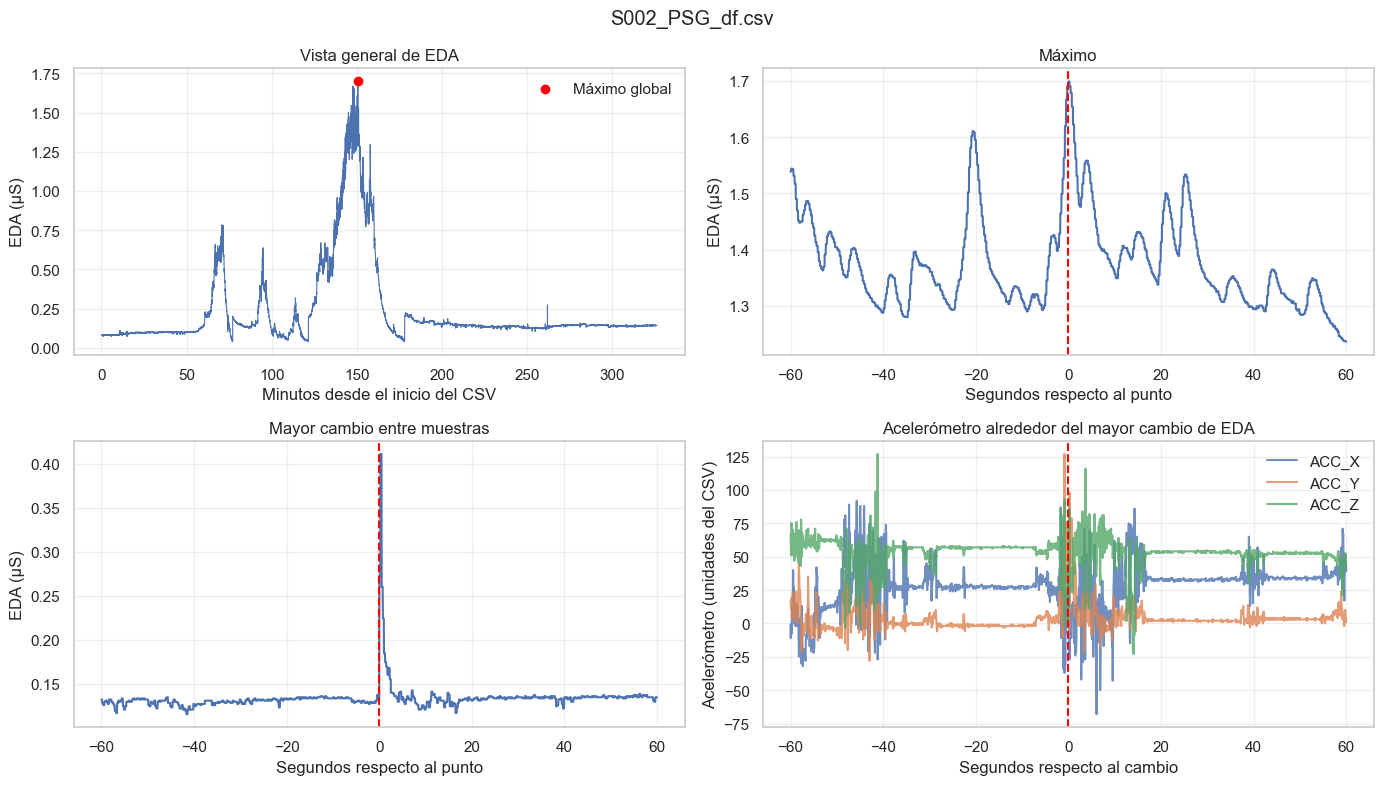


Inspeccionando EDA: S004_PSG_df.csv


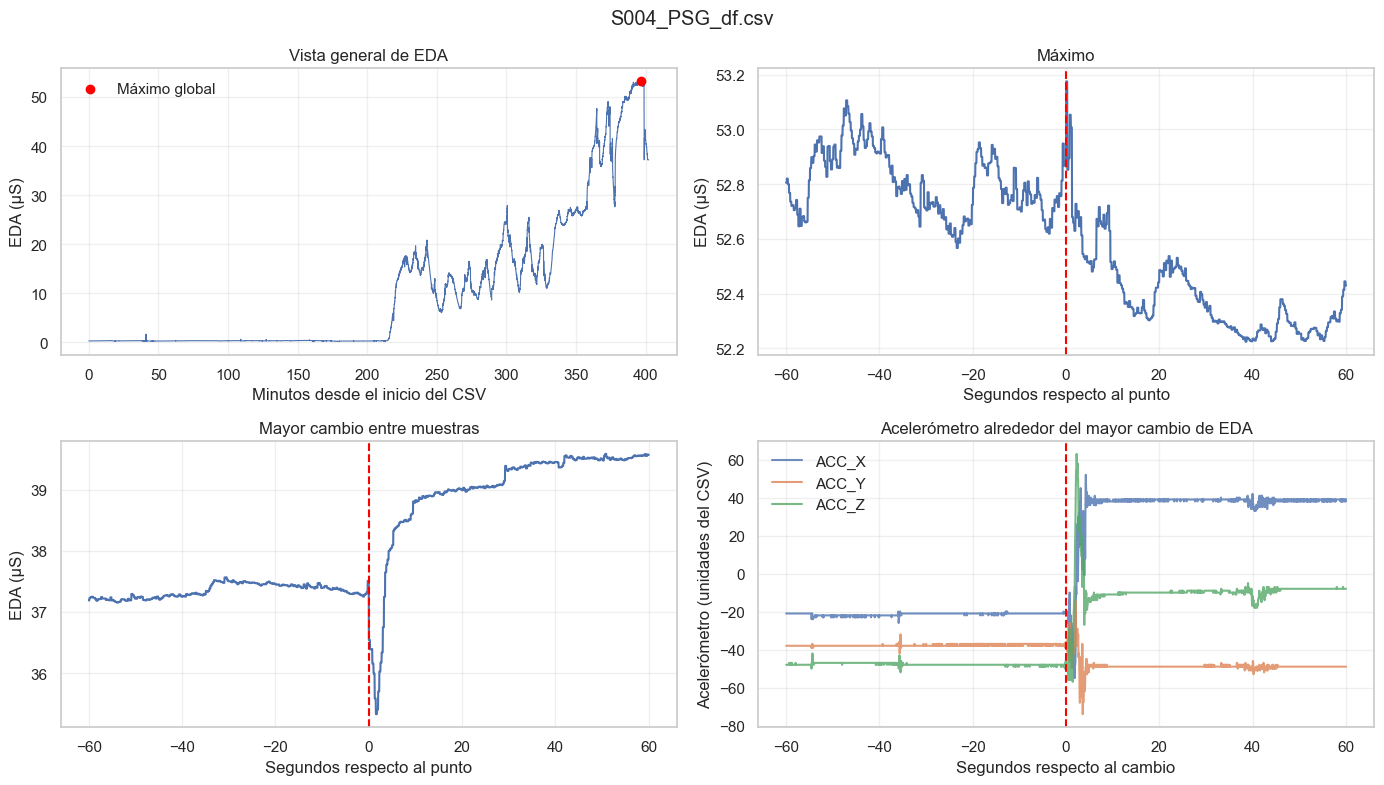


ESTADÍSTICAS DE EDA POR PACIENTE


,count,mean,std,min,1%,25%,50%,75%,99%,max,archivo,valores_negativos,mayor_cambio_absoluto
0,1958400.0,0.231192,0.26747,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764,S002_PSG_df.csv,0,0.130614
1,2413100.0,10.635652,14.41238,0.102755,0.207805,0.280828,0.324385,16.530336,52.520241,53.174881,S004_PSG_df.csv,0,0.912041



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,EDA,EDA_anterior,cambio_entre_muestras
0,S002_PSG_df.csv,Máximo,903539,20915.39,1.698764,1.698090,0.000674
1,S002_PSG_df.csv,Mayor cambio entre muestras,1571881,27598.81,0.272808,0.142194,0.130614
2,S004_PSG_df.csv,Máximo,2381748,30657.48,53.174881,52.904557,0.270324
3,S004_PSG_df.csv,Mayor cambio entre muestras,2167659,28516.59,36.541969,37.454010,-0.912041



No se modificaron valores. La vista general puede ocultar eventos breves por su muestreo visual; los gráficos locales utilizan todas las muestras. Los valores elevados o el movimiento coincidente no confirman por sí solos un error.


In [24]:
# 2.6.4. Inspección de EDA y contexto de movimiento

carpeta_revision = Path("/kaggle/working/auditoria")

auditoria_eda = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_eda = auditoria_eda.loc[
    auditoria_eda["señal"].eq("EDA"),
    ["archivo", "minimo", "maximo", "nulos", "infinitos"],
].sort_values("maximo", ascending=False)

print("DIEZ MAYORES MÁXIMOS DE EDA")
display(rangos_eda.head(10))

pacientes_eda_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S057_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_eda = [
    nombre for nombre in pacientes_eda_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_eda:
    nombres_revision_eda = [p.name for p in data_files[:3]]

columnas_leer = [
    "TIMESTAMP", "EDA", "ACC_X", "ACC_Y", "ACC_Z"
]
estadisticas_eda = []
puntos_revision_eda = []

for nombre in nombres_revision_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando EDA: {nombre}", flush=True)

    if ruta == sample_file:
        datos = df_sample_eda[columnas_leer].copy()
    else:
        datos = pd.read_csv(ruta, usecols=columnas_leer)

    datos = datos.reset_index(drop=True)

    valores = pd.to_numeric(datos["EDA"], errors="coerce")
    tiempos = pd.to_numeric(
        datos["TIMESTAMP"], errors="coerce"
    )
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        del datos
        continue

    diferencias = finitos.diff()
    diferencias_absolutas = diferencias.abs()

    if not diferencias_absolutas.notna().any():
        print("No hay pares válidos para calcular cambios.")
        del datos
        continue

    posicion_maximo = int(finitos.idxmax())
    posicion_cambio = int(diferencias_absolutas.idxmax())

    resumen = finitos.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).to_dict()
    resumen["archivo"] = nombre
    resumen["valores_negativos"] = int(finitos.lt(0).sum())
    resumen["mayor_cambio_absoluto"] = float(
        diferencias_absolutas.iloc[posicion_cambio]
    )
    estadisticas_eda.append(resumen)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # 1. Vista general: tomar una muestra por segundo para dibujar.
    # Solo reduce los puntos del gráfico; no cambia los datos analizados.
    posiciones_vista = np.arange(0, len(datos), 100)

    axes[0, 0].plot(
        (tiempos.iloc[posiciones_vista] - tiempos.iloc[0]) / 60,
        valores.iloc[posiciones_vista],
        linewidth=0.8,
    )
    axes[0, 0].scatter(
        (tiempos.iloc[posicion_maximo] - tiempos.iloc[0]) / 60,
        valores.iloc[posicion_maximo],
        color="red",
        label="Máximo global",
        zorder=5,
    )
    axes[0, 0].set_title("Vista general de EDA")
    axes[0, 0].set_xlabel("Minutos desde el inicio del CSV")
    axes[0, 0].set_ylabel("EDA (µS)")
    axes[0, 0].legend()

    # 2 y 3. Hasta 60 segundos alrededor del máximo y mayor cambio.
    for ax, motivo, posicion in [
        (axes[0, 1], "Máximo", posicion_maximo),
        (axes[1, 0], "Mayor cambio entre muestras", posicion_cambio),
    ]:
        inicio = max(0, posicion - 6000)
        fin = min(len(datos), posicion + 6001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(motivo)
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("EDA (µS)")

        puntos_revision_eda.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "EDA": valores.iloc[posicion],
            "EDA_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
            "cambio_entre_muestras": diferencias.iloc[posicion],
        })

    # 4. Acelerómetro en el MISMO intervalo del mayor cambio de EDA.
    inicio = max(0, posicion_cambio - 6000)
    fin = min(len(datos), posicion_cambio + 6001)
    tiempo_relativo = (
        tiempos.iloc[inicio:fin] - tiempos.iloc[posicion_cambio]
    )

    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[1, 1].plot(
            tiempo_relativo,
            pd.to_numeric(
                datos[eje].iloc[inicio:fin], errors="coerce"
            ),
            label=eje,
            alpha=0.8,
        )

    axes[1, 1].axvline(0, color="red", linestyle="--")
    axes[1, 1].set_title(
        "Acelerómetro alrededor del mayor cambio de EDA"
    )
    axes[1, 1].set_xlabel("Segundos respecto al cambio")
    axes[1, 1].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[1, 1].legend()

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    fig.suptitle(nombre)
    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos
    del diferencias, diferencias_absolutas

estadisticas_eda = pd.DataFrame(estadisticas_eda)
puntos_revision_eda = pd.DataFrame(puntos_revision_eda)

print("\nESTADÍSTICAS DE EDA POR PACIENTE")
display(estadisticas_eda.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_eda)

estadisticas_eda.to_csv(
    carpeta_revision / "revision_estadisticas_eda.csv",
    index=False,
)
puntos_revision_eda.to_csv(
    carpeta_revision / "revision_puntos_eda.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "La vista general puede ocultar eventos breves por su muestreo "
    "visual; los gráficos locales utilizan todas las muestras. "
    "Los valores elevados o el movimiento coincidente no confirman "
    "por sí solos un error."
)

# 3. Preparación y evaluación del dataset de epochs
Preparamos una tabla con una fila por paciente y epoch completo de 30 segundos.

- Se verifica continuidad a 100 Hz y se infiere la alineación a partir de los cambios entre etapas válidas.
- Se definen los epochs antes de filtrar filas. Se contabilizan los fragmentos incompletos.
- Se conservan las señales originales, incluidos sus posibles nulos. El recorte por percentiles y la interpolación automática están desactivados.
- Las anotaciones respiratorias no se utilizan como predictores; sí se conservan las señales fisiológicas respiratorias.
- Se calculan media, desviación estándar, mediana y cobertura de cada señal por epoch.

La documentación de DREAMT indica que la preparación (`P`) aparece como `W` en los archivos de 100 Hz. Por eso, `W` por sí solo no permite distinguir preparación de vigilia real.

Fuente del dataset: [DREAMT 2.2.0](https://physionet.org/content/dreamt/2.2.0/).

In [25]:
# Funciones Modulares de Limpieza a 100 Hz

def clean_sleep_stages(df):
    """Conserva filas, orden y etiquetas antes del agrupamiento temporal."""
    if "Sleep_Stage" not in df.columns:
        raise ValueError("Falta la columna Sleep_Stage.")

    return df.copy()


def clean_sao2(df):
    """
    Conserva SAO2 original, incluidos sus posibles faltantes.

    No aplica umbrales ni interpolación automática mientras
    esas reglas no estén justificadas.
    """
    return df

def clean_outliers_wearable_psg(df):
    """
    Conserva las señales originales.

    El recorte por percentiles y el relleno de nulos quedan
    desactivados hasta justificar sus reglas con evidencia.
    """
    return df

def run_etl_pipeline(df):
    """Prepara señales para predecir la etapa de sueño."""
    df = clean_sleep_stages(df)
    df = clean_sao2(df)
    df = clean_outliers_wearable_psg(df)
    return df

## 3.1. Generación de la primera versión del dataset de epochs

Se procesan los registros completos, con ventanas de 30 segundos
alineadas por paciente.

S027 y S048 quedan pendientes por su alineación inconsistente.
S097 queda pendiente por sus señales PSG constantes.

SAO2 e IBI se excluyen provisionalmente de las características.
Las demás señales se conservan sin recortes ni imputación automática.

Se mantienen únicamente epochs completos con una misma etiqueta
válida en las 3000 muestras. Las exclusiones se registran.
Los epochs se guardan en una única tabla conjunta. En local, las tres salidas se escriben en `etl_v1/` dentro del directorio de trabajo; en Kaggle, en `/kaggle/working/etl_v1/`. La ruta absoluta se imprime al comenzar. Las exclusiones de pacientes y la trazabilidad de ventanas quedan en la auditoría del ETL.

In [26]:
# 3.1. Primera versión del dataset de epochs

# En Kaggle, guardar en /kaggle/working; en local, junto al notebook.
es_kaggle = os.name != "nt" and (
    "KAGGLE_KERNEL_RUN_TYPE" in os.environ
    or Path("/kaggle/input").exists()
)
carpeta_etl = (
    Path("/kaggle/working/etl_v1")
    if es_kaggle else Path.cwd() / "etl_v1"
)
carpeta_etl.mkdir(parents=True, exist_ok=True)
print("Carpeta de salida ETL:", carpeta_etl.resolve())

# Exclusiones provisionales justificadas por la auditoría.
motivos_exclusion = {
    "S027_PSG_df.csv": "Alineación inconsistente",
    "S048_PSG_df.csv": "Alineación inconsistente",
    "S097_PSG_df.csv": "Señales PSG constantes durante todo el registro",
}

archivos_procesar = [
    p for p in data_files if p.name not in motivos_exclusion
]

if not data_files:
    raise ValueError("No se encontraron archivos de pacientes.")

if len({p.name for p in data_files}) != len(data_files):
    raise ValueError("Hay nombres de archivos duplicados.")

if not archivos_procesar:
    raise ValueError("No quedaron pacientes para procesar tras las exclusiones.")

print("Archivos encontrados:", len(data_files))
print("Pacientes excluidos:", len(data_files) - len(archivos_procesar))

window_size = 3000
etapas_validas = ["W", "N1", "N2", "N3", "R"]

wearable_cols = [
    "BVP", "HR", "EDA", "TEMP",
    "ACC_X", "ACC_Y", "ACC_Z",
]

psg_cols = [
    "C4-M1", "F4-M1", "O2-M1", "Fp1-O2",
    "T3 - CZ", "CZ - T4", "CHIN", "E1", "E2",
    "ECG", "LAT", "RAT", "SNORE", "PTAF",
    "FLOW", "THORAX", "ABDOMEN",
]

senales_modelo = wearable_cols + psg_cols
columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales_modelo

resultados_epochs = []
resumen_temporal = [
    {
        "patient_id": extract_patient_id(file_path),
        "archivo": file_path.name,
        "estado": "excluido",
        "motivo_exclusion": motivos_exclusion[file_path.name],
        "continuidad_temporal": "no evaluada",
    }
    for file_path in data_files
    if file_path.name in motivos_exclusion
]
exclusiones_epochs = []

print("Pacientes a procesar:", len(archivos_procesar))
print("Señales incluidas:", len(senales_modelo))

for numero, file_path in enumerate(archivos_procesar, start=1):
    patient_id = extract_patient_id(file_path)

    print(
        f"[{numero}/{len(archivos_procesar)}] {file_path.name}",
        flush=True,
    )

    # Leer solo las columnas utilizadas en esta versión.
    df_raw = pd.read_csv(
        file_path,
        usecols=columnas_leer,
        low_memory=False,
    )

    # Definir ventanas sobre posiciones originales.
    epoch_ids, completos, diagnostico = definir_epochs(df_raw)
    timestamp_inicio_csv = df_raw["TIMESTAMP"].iloc[0]

    df_raw["epoch"] = epoch_ids
    df_raw = df_raw.loc[completos].copy()

    grupos = df_raw.groupby("epoch", sort=True)

    # Agregación directa: no ejecutar una función Python por epoch.
    estadisticas = grupos[senales_modelo].agg(
        ["mean", "std", "median", "count"]
    )

    estadisticas.columns = [
        f"{senal}_{'n_valid' if operacion == 'count' else operacion}"
        for senal, operacion in estadisticas.columns
    ]

    for senal in senales_modelo:
        estadisticas[f"{senal}_missing_frac"] = (
            1 - estadisticas[f"{senal}_n_valid"] / window_size
        )

    # Contar solamente etiquetas válidas, conservando las posiciones.
    etiquetas_validas = df_raw["Sleep_Stage"].where(
        df_raw["Sleep_Stage"].isin(etapas_validas)
    )

    conteos_etapas = (
        etiquetas_validas.groupby(df_raw["epoch"])
        .value_counts()
        .unstack(fill_value=0)
        .reindex(
            index=estadisticas.index,
            columns=etapas_validas,
            fill_value=0,
        )
        .fillna(0)
    )

    mayor_conteo = conteos_etapas.max(axis=1)

    # Si no hay etiquetas válidas, el objetivo permanece faltante.
    objetivo = conteos_etapas.idxmax(axis=1).where(
        mayor_conteo.gt(0)
    )
    pureza = mayor_conteo / window_size

    estadisticas["TIMESTAMP"] = grupos["TIMESTAMP"].first()
    estadisticas["tiempo_relativo_segundos"] = (
        estadisticas["TIMESTAMP"] - timestamp_inicio_csv
    )
    estadisticas["Sleep_Stage"] = objetivo
    estadisticas["porcentaje_pureza"] = pureza

    # Primera versión: conservar únicamente epochs completamente puros.
    conservar = mayor_conteo.eq(window_size)

    descartados = pd.DataFrame({
        "epoch": estadisticas.index,
        "porcentaje_pureza": pureza.to_numpy(),
        "muestras_con_etiqueta_valida":
            conteos_etapas.sum(axis=1).to_numpy(),
    }).loc[~conservar.to_numpy()].copy()

    if not descartados.empty:
        descartados.insert(0, "archivo", file_path.name)
        descartados.insert(0, "patient_id", patient_id)
        descartados["motivo"] = (
            "No contiene 3000 muestras de una misma etapa válida"
        )
        exclusiones_epochs.append(descartados)

    df_epochs = estadisticas.loc[conservar].reset_index()
    df_epochs.insert(0, "patient_id", patient_id)

    # Optimizar memoria de características, conservando tiempos en float64.
    columnas_estadisticas = [
        c for c in df_epochs.columns
        if c.endswith(("_mean", "_std", "_median", "_missing_frac"))
    ]
    df_epochs[columnas_estadisticas] = (
        df_epochs[columnas_estadisticas].astype("float32")
    )

    diagnostico.update({
        "patient_id": patient_id,
        "archivo": file_path.name,
        "alcance": "Registro completo",
        "estado": "procesado",
        "motivo_exclusion": "",
        "continuidad_temporal": "verificada",
        "epochs_descartados_por_pureza": int((~conservar).sum()),
        "epochs_conservados": len(df_epochs),
    })

    resultados_epochs.append(df_epochs)
    resumen_temporal.append(diagnostico)

    # Actualizar la auditoría sin generar datasets por paciente.
    pd.DataFrame(resumen_temporal).to_csv(
        carpeta_etl / "auditoria_epochs.csv",
        index=False,
    )

    print(
        f"  Conservados: {len(df_epochs)} | "
        f"Descartados: {int((~conservar).sum())}",
        flush=True,
    )

    del df_raw, grupos, estadisticas, conteos_etapas
    del etiquetas_validas, objetivo, pureza, mayor_conteo
    gc.collect()

# Consolidar resultados.
df_epochs_all = pd.concat(resultados_epochs, ignore_index=True)
auditoria_epochs = pd.DataFrame(resumen_temporal)

if exclusiones_epochs:
    epochs_descartados = pd.concat(
        exclusiones_epochs, ignore_index=True
    )
else:
    epochs_descartados = pd.DataFrame(columns=[
        "patient_id", "archivo", "epoch", "porcentaje_pureza",
        "muestras_con_etiqueta_valida", "motivo",
    ])

# Verificar que la auditoría explique todos los archivos y epochs.
if len(auditoria_epochs) != len(data_files):
    raise ValueError("La auditoría no incluye todos los archivos detectados.")

if auditoria_epochs["archivo"].duplicated().any():
    raise ValueError("La auditoría contiene archivos duplicados.")

if auditoria_epochs["patient_id"].duplicated().any():
    raise ValueError("Hay identificadores de paciente duplicados.")

procesados = auditoria_epochs.loc[
    auditoria_epochs["estado"].eq("procesado")
].copy()

if len(procesados) != len(archivos_procesar):
    raise ValueError("La auditoría no coincide con los pacientes procesados.")

if not (
    procesados["filas_originales"]
    == procesados["filas_fragmento_inicial"]
    + procesados["epochs_completos"] * window_size
    + procesados["filas_fragmento_final"]
).all():
    raise ValueError("Las filas originales no cuadran con los epochs y fragmentos.")

if not (
    procesados["epochs_completos"]
    == procesados["epochs_descartados_por_pureza"]
    + procesados["epochs_conservados"]
).all():
    raise ValueError("Los epochs completos no cuadran con conservados y descartados.")

conservados_por_paciente = df_epochs_all.groupby("patient_id").size()
if not procesados["epochs_conservados"].eq(
    procesados["patient_id"].map(conservados_por_paciente).fillna(0)
).all():
    raise ValueError("La auditoría no coincide con el dataset consolidado.")

if int(procesados["epochs_descartados_por_pureza"].sum()) != len(
    epochs_descartados
):
    raise ValueError("La auditoría no coincide con los epochs descartados.")

# Validar identidad, etiquetas y orden antes de guardar.
if df_epochs_all.empty:
    raise ValueError("No se conservaron epochs para el dataset final.")

if df_epochs_all[["patient_id", "epoch"]].isna().any().any():
    raise ValueError("Hay claves patient_id/epoch faltantes.")

if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

if not df_epochs_all["Sleep_Stage"].isin(etapas_validas).all():
    raise ValueError("Hay etapas de sueño inválidas en el dataset final.")

df_epochs_all = df_epochs_all.sort_values(
    ["patient_id", "epoch"]
).reset_index(drop=True)

if not pd.MultiIndex.from_frame(
    df_epochs_all[["patient_id", "epoch"]]
).is_monotonic_increasing:
    raise ValueError("Los epochs no quedaron ordenados por paciente.")

df_epochs_all.to_csv(
    carpeta_etl / "dataset_epochs_v1.csv", index=False
)
epochs_descartados.to_csv(
    carpeta_etl / "epochs_descartados.csv", index=False
)

print("\nETL FINALIZADO")
print("Pacientes con epochs conservados:",
      df_epochs_all["patient_id"].nunique())
print("Dimensiones:", df_epochs_all.shape)
print("Epochs descartados:", len(epochs_descartados))

print("\nEPOCHS POR ETAPA")
print(df_epochs_all["Sleep_Stage"].value_counts().to_string())

print("\nNULOS EN EL RESULTADO")
nulos = df_epochs_all.isna().sum()
nulos = nulos[nulos.gt(0)]
print(nulos.to_string() if not nulos.empty else "Sin nulos.")

print("\nResultados guardados en:", carpeta_etl)

Archivos encontrados: 18
Pacientes excluidos: 0
Pacientes a procesar: 18
Señales incluidas: 24
[1/18] S002_PSG_df.csv
  Conservados: 652 | Descartados: 0
[2/18] S003_PSG_df.csv
  Conservados: 773 | Descartados: 0
[3/18] S004_PSG_df.csv
  Conservados: 804 | Descartados: 0
[4/18] S005_PSG_df.csv
  Conservados: 730 | Descartados: 0
[5/18] S006_PSG_df.csv
  Conservados: 801 | Descartados: 0
[6/18] S007_PSG_df.csv
  Conservados: 797 | Descartados: 0
[7/18] S008_PSG_df.csv
  Conservados: 743 | Descartados: 0
[8/18] S009_PSG_df.csv
  Conservados: 766 | Descartados: 0
[9/18] S010_PSG_df.csv
  Conservados: 795 | Descartados: 0
[10/18] S016_PSG_df.csv
  Conservados: 750 | Descartados: 0
[11/18] S017_PSG_df.csv
  Conservados: 770 | Descartados: 0
[12/18] S019_PSG_df.csv
  Conservados: 691 | Descartados: 0
[13/18] S082_PSG_df.csv
  Conservados: 660 | Descartados: 0
[14/18] S083_PSG_df.csv
  Conservados: 731 | Descartados: 0
[15/18] S084_PSG_df.csv
  Conservados: 687 | Descartados: 0
[16/18] S086_P

### 3.2. Resumen Post-ETL y Consolidación

--- Resumen del Resultado Actual del ETL ---
Dimensiones de df_epochs_all: (13165, 126) (Filas/Epochs x 126 Columnas/Features)
Memoria consumida en RAM: 8.37 MB
Total de valores nulos globales post-ETL: 0

Pacientes incluidos: 18


,filas_originales,desplazamiento,epochs_completos,filas_fragmento_inicial,filas_fragmento_final,patient_id,archivo,alcance,estado,motivo_exclusion,continuidad_temporal,epochs_descartados_por_pureza,epochs_conservados
0,1958400,2400,652,2400,0,2,S002_PSG_df.csv,Registro completo,procesado,,verificada,0,652
1,2321400,2400,773,2400,0,3,S003_PSG_df.csv,Registro completo,procesado,,verificada,0,773
2,2413100,1100,804,1100,0,4,S004_PSG_df.csv,Registro completo,procesado,,verificada,0,804
3,2191300,1300,730,1300,0,5,S005_PSG_df.csv,Registro completo,procesado,,verificada,0,730
4,2403000,0,801,0,0,6,S006_PSG_df.csv,Registro completo,procesado,,verificada,0,801
5,2391000,0,797,0,0,7,S007_PSG_df.csv,Registro completo,procesado,,verificada,0,797
6,2231500,2500,743,2500,0,8,S008_PSG_df.csv,Registro completo,procesado,,verificada,0,743
7,2298400,400,766,400,0,9,S009_PSG_df.csv,Registro completo,procesado,,verificada,0,766
8,2385100,100,795,100,0,10,S010_PSG_df.csv,Registro completo,procesado,,verificada,0,795
9,2250400,400,750,400,0,16,S016_PSG_df.csv,Registro completo,procesado,,verificada,0,750


--- Diccionario de Datos ---


,Columna,Tipo de Dato,Significado
0,patient_id,int64,ID numérico único por paciente
1,epoch,int64,Índice secuencial del bloque de 30s
2,BVP_mean,float32,Promedio de la señal BVP durante el epoch de 30s
3,BVP_std,float32,Desviación estándar de la señal BVP en el epoch
4,BVP_median,float32,Mediana de la señal BVP en el epoch
5,BVP_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)
6,HR_mean,float32,Promedio de la señal HR durante el epoch de 30s
7,HR_std,float32,Desviación estándar de la señal HR en el epoch
8,HR_median,float32,Mediana de la señal HR en el epoch
9,HR_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)



--- Distribución de Clases del Resultado Actual (Sleep_Stage) ---


Sleep_Stage
N2    5744
W     4267
N1    1589
R     1127
N3     438
Name: count, dtype: int64

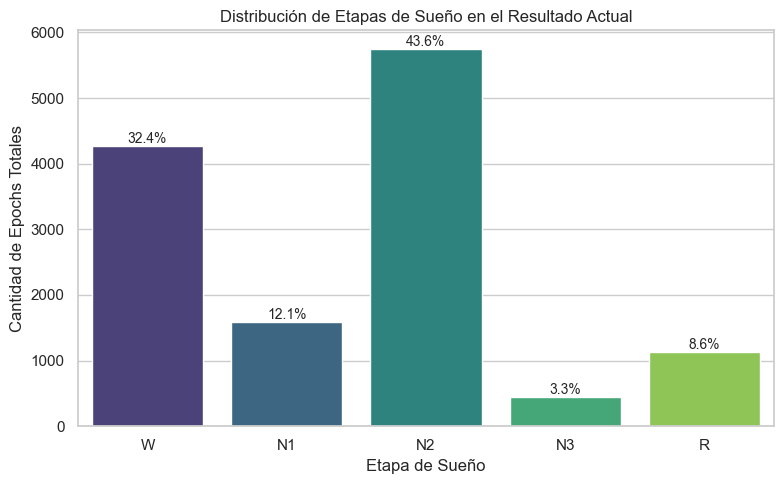

In [37]:
# Mostrar dimensiones del resultado actual

if 'df_epochs_all' in globals() and not df_epochs_all.empty:
    print("--- Resumen del Resultado Actual del ETL ---")
    num_cols = df_epochs_all.shape[1]
    print(f"Dimensiones de df_epochs_all: {df_epochs_all.shape} (Filas/Epochs x {num_cols} Columnas/Features)")
    
    # Memoria consumida (en MB)
    mem_mb = df_epochs_all.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memoria consumida en RAM: {mem_mb:.2f} MB")
    
    # Verificación de nulos
    total_nulls = df_epochs_all.isnull().sum().sum()
    print(f"Total de valores nulos globales post-ETL: {total_nulls}\n")
    
    print('Pacientes incluidos:', df_epochs_all['patient_id'].nunique())
    if 'auditoria_epochs' in globals():
        display(auditoria_epochs)

    print("--- Diccionario de Datos ---")
    # Generar tabla de definición de columnas
    def get_column_meaning(col):
        if col == 'patient_id': return 'ID numérico único por paciente'
        if col == 'epoch': return 'Índice secuencial del bloque de 30s'
        if col == 'tiempo_relativo_segundos': return 'Segundos desde el inicio del CSV original'
        if col == 'TIMESTAMP': return 'Marca de tiempo original del inicio del epoch'
        if col == 'Sleep_Stage': return 'Etapa única válida en las 3000 muestras del epoch conservado'
        if col == 'porcentaje_pureza': return 'Proporción de muestras que coinciden con la etapa de sueño dominante'
        if col.endswith('_mean'): return f"Promedio de la señal {col.replace('_mean', '')} durante el epoch de 30s"
        if col.endswith('_std'): return f"Desviación estándar de la señal {col.replace('_std', '')} en el epoch"
        if col.endswith('_median'): return f"Mediana de la señal {col.replace('_median', '')} en el epoch"
        if col.endswith('_missing_frac'): return 'Fracción de muestras nulas dentro del epoch (0 a 1)'
        if col.endswith('_n_valid'): return 'Cantidad de muestras no nulas dentro del epoch (0 a 3000)'
        return 'Variable no catalogada'

    data_dict = []
    for col in df_epochs_all.columns:
        data_dict.append({
            'Columna': col,
            'Tipo de Dato': str(df_epochs_all[col].dtype),
            'Significado': get_column_meaning(col)
        })
    df_diccionario = pd.DataFrame(data_dict)
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(df_diccionario)
    
    # Distribución de Sleep_Stage (Variable Objetivo)
    print("\n--- Distribución de Clases del Resultado Actual (Sleep_Stage) ---")
    stage_counts = df_epochs_all['Sleep_Stage'].value_counts()
    display(stage_counts)
    
    # Gráfico
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_epochs_all, x='Sleep_Stage', order=['W', 'N1', 'N2', 'N3', 'R'], palette='viridis')
    plt.title('Distribución de Etapas de Sueño en el Resultado Actual')
    plt.xlabel('Etapa de Sueño')
    plt.ylabel('Cantidad de Epochs Totales')
    
    # Añadir porcentajes al gráfico
    for p in plt.gca().patches:
        height = p.get_height()
        if height > 0:
            plt.gca().annotate(f'{height/len(df_epochs_all):.1%}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("El dataframe df_epochs_all no está definido.")

### Decisiones tomadas

- La alineación se verifica por paciente; no existe un offset fijo común de 2400 filas.
- Se conserva la vigilia en los epochs completos. Los fragmentos se identifican por duración, no por su etapa.
- Las señales no se recortan ni rellenan automáticamente: faltan criterios justificados para esas intervenciones.
- Los nulos se conservan y su cobertura se registra por señal y epoch.
- Las anotaciones de apnea quedan fuera del dataset del modelo.
- Se conservan solo epochs completos con una única etapa válida en sus 3000 muestras; no se aplica un umbral del 60 %.

Los resultados del resumen corresponden exclusivamente a los archivos y filas configurados en 3.1.

## 3.3. Distribución global de etapas y señales

Esta comparación reúne los epochs de todos los pacientes procesados. Muestra cuántos epochs y pacientes aportan a cada etapa, y cómo se distribuyen las características seleccionadas. Un paciente con más epochs influye más en las cajas globales; los gráficos no demuestran utilidad predictiva ni sustituyen una revisión individual cuando aparece un patrón dudoso. Los valores atípicos no se muestran como puntos para mantener legibilidad, pero permanecen en los datos y se revisan por separado.

COBERTURA GLOBAL POR ETAPA


,epochs,porcentaje_epochs,pacientes
Sleep_Stage,,,
W,4267,32.41,18
N1,1589,12.07,18
N2,5744,43.63,18
N3,438,3.33,7
R,1127,8.56,14


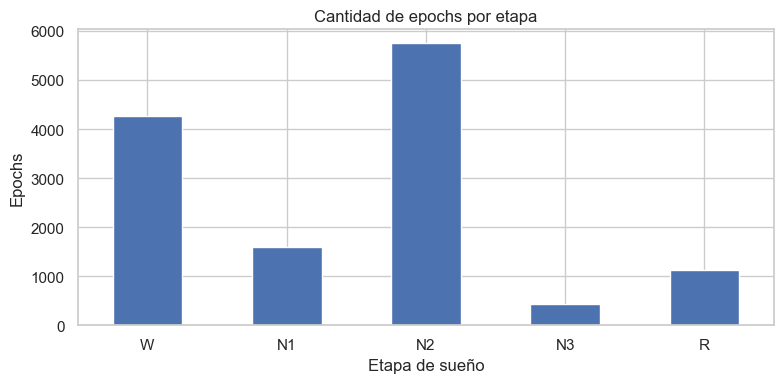

Características no disponibles en esta versión: ['SAO2_mean']
COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA


,caracteristica,Sleep_Stage,epochs_con_valor,epochs_totales,pacientes,muestras_faltantes_pct
0,HR_mean,W,4267,4267,18,0.0
1,HR_mean,N1,1589,1589,18,0.0
2,HR_mean,N2,5744,5744,18,0.0
3,HR_mean,N3,438,438,7,0.0
4,HR_mean,R,1127,1127,14,0.0
5,TEMP_mean,W,4267,4267,18,0.0
6,TEMP_mean,N1,1589,1589,18,0.0
7,TEMP_mean,N2,5744,5744,18,0.0
8,TEMP_mean,N3,438,438,7,0.0
9,TEMP_mean,R,1127,1127,14,0.0


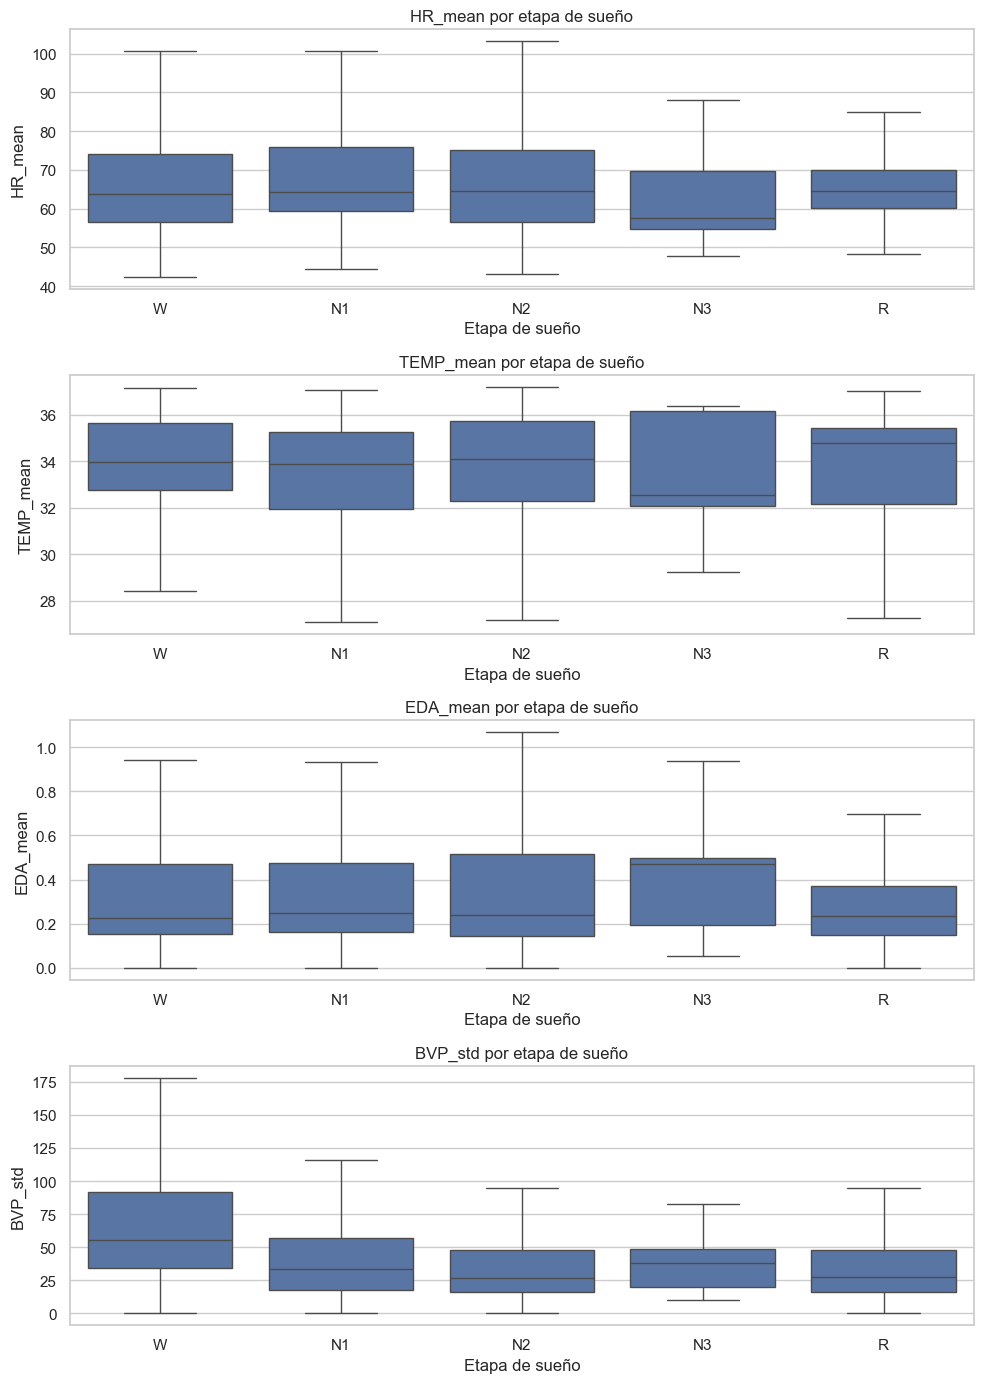

Cada observación es un epoch. Las cajas resumen datos agrupados de todos los pacientes; no representan al paciente típico. Los valores atípicos no se dibujan como puntos, pero no se eliminaron del dataset. Revisar patrones dudosos por paciente.


In [38]:
# 3.3. Comparación global por etapa de sueño
orden_etapas = ["W", "N1", "N2", "N3", "R"]

if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_requeridas = {
    "patient_id", "epoch", "Sleep_Stage", "porcentaje_pureza"
}
faltantes = columnas_requeridas.difference(df_epochs_all.columns)
if faltantes:
    raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etiquetas de sueño faltantes o inválidas.")

if not df_epochs_all["porcentaje_pureza"].eq(1.0).all():
    raise ValueError("Hay epochs no puros. Revisarlos antes de comparar.")

conteos_etapa = df_epochs_all["Sleep_Stage"].value_counts().reindex(
    orden_etapas, fill_value=0
)
pacientes_etapa = (
    df_epochs_all.groupby("Sleep_Stage")["patient_id"]
    .nunique()
    .reindex(orden_etapas, fill_value=0)
)
resumen_etapas = pd.DataFrame({
    "epochs": conteos_etapa,
    "porcentaje_epochs": 100 * conteos_etapa / len(df_epochs_all),
    "pacientes": pacientes_etapa,
})
resumen_etapas.index.name = "Sleep_Stage"

print("COBERTURA GLOBAL POR ETAPA")
display(resumen_etapas.round(2))

ax = conteos_etapa.plot.bar(figsize=(8, 4), rot=0)
ax.set_title("Cantidad de epochs por etapa")
ax.set_xlabel("Etapa de sueño")
ax.set_ylabel("Epochs")
plt.tight_layout()
plt.show()

caracteristicas_propuestas = [
    "HR_mean", "TEMP_mean", "EDA_mean", "BVP_std", "SAO2_mean"
]
caracteristicas = [
    col for col in caracteristicas_propuestas if col in df_epochs_all.columns
]
no_disponibles = sorted(set(caracteristicas_propuestas) - set(caracteristicas))
if no_disponibles:
    print("Características no disponibles en esta versión:", no_disponibles)
if not caracteristicas:
    raise ValueError("No hay características disponibles para graficar.")

resumen_cobertura = []
for caracteristica in caracteristicas:
    valores_validos = (
        df_epochs_all.groupby("Sleep_Stage")[caracteristica]
        .count()
        .reindex(orden_etapas, fill_value=0)
    )
    señal = caracteristica.rsplit("_", 1)[0]
    columna_faltantes = f"{señal}_missing_frac"

    for etapa in orden_etapas:
        registro = {
            "caracteristica": caracteristica,
            "Sleep_Stage": etapa,
            "epochs_con_valor": int(valores_validos[etapa]),
            "epochs_totales": int(conteos_etapa[etapa]),
            "pacientes": int(pacientes_etapa[etapa]),
        }
        if columna_faltantes in df_epochs_all.columns:
            fraccion = df_epochs_all.loc[
                df_epochs_all["Sleep_Stage"].eq(etapa),
                columna_faltantes,
            ].mean()
            registro["muestras_faltantes_pct"] = 100 * fraccion
        resumen_cobertura.append(registro)

print("COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA")
display(pd.DataFrame(resumen_cobertura).round(2))

fig, axes = plt.subplots(
    len(caracteristicas), 1,
    figsize=(10, 3.5 * len(caracteristicas)),
    squeeze=False,
)
for fila, caracteristica in enumerate(caracteristicas):
    ax = axes[fila, 0]
    sns.boxplot(
        data=df_epochs_all,
        x="Sleep_Stage",
        y=caracteristica,
        order=orden_etapas,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(f"{caracteristica} por etapa de sueño")
    ax.set_xlabel("Etapa de sueño")
    ax.set_ylabel(caracteristica)

plt.tight_layout()
plt.show()

print(
    "Cada observación es un epoch. Las cajas resumen datos agrupados "
    "de todos los pacientes; no representan al paciente típico. "
    "Los valores atípicos no se dibujan como puntos, pero no se "
    "eliminaron del dataset. Revisar patrones dudosos por paciente."
)

## 3.3.1. Revisión exploratoria de valores atípicos

Se marcan valores alejados del rango intercuartílico global (1,5 × IQR) en características seleccionadas de wearable y PSG. Es una regla descriptiva, no un límite fisiológico ni una limpieza: una distribución asimétrica puede producir muchos candidatos legítimos. Se resumen la cantidad de epochs y pacientes afectados y la proporción por etapa. La lista de casos muestra cobertura de la señal y epochs vecinos del mismo paciente para orientar la revisión. No se modifica `df_epochs_all`; cualquier recorte, exclusión o imputación requiere una decisión posterior documentada en el ADR 0005.


In [39]:
# 3.3.1. Candidatos atípicos: marcas descriptivas, sin cambiar el dataset
variables_revision = [
    "HR_mean", "HR_std", "TEMP_mean", "EDA_mean", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] + [f"{senal}_std" for senal in psg_cols]
variables_revision = list(dict.fromkeys(
    col for col in variables_revision if col in df_epochs_all.columns
))
if not variables_revision:
    raise ValueError("No hay características disponibles para revisar atípicos.")

base_revision = df_epochs_all.sort_values(["patient_id", "epoch"])
resumen_atipicos = []
resumen_atipicos_etapa = []
casos_atipicos = []

for variable in variables_revision:
    valores = pd.to_numeric(base_revision[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    fila = {
        "variable": variable,
        "epochs_validos": int(validos.sum()),
        "epochs_sin_valor_finito": int((~validos).sum()),
    }
    if validos.sum() < 4:
        fila.update({"criterio": "insuficientes datos", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    q1, q3 = valores.loc[validos].quantile([0.25, 0.75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        fila.update({"criterio": "IQR nulo", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    marcados = validos & (
        (valores < limite_inferior) | (valores > limite_superior)
    )
    fila.update({
        "criterio": "1,5 × IQR global",
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "epochs_marcados": int(marcados.sum()),
        "porcentaje_validos": 100 * marcados.sum() / validos.sum(),
        "pacientes_marcados": base_revision.loc[marcados, "patient_id"].nunique(),
    })
    resumen_atipicos.append(fila)

    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = base_revision["Sleep_Stage"].eq(etapa)
        n_validos = int((validos & en_etapa).sum())
        n_marcados = int((marcados & en_etapa).sum())
        resumen_atipicos_etapa.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_validos": n_validos,
            "epochs_marcados": n_marcados,
            "porcentaje_validos": 100 * n_marcados / n_validos if n_validos else np.nan,
        })

    if not marcados.any():
        continue
    casos = base_revision.loc[
        marcados, ["patient_id", "epoch", "Sleep_Stage"]
    ].copy()
    casos["variable"] = variable
    casos["valor"] = valores.loc[marcados]
    casos["limite_inferior"] = limite_inferior
    casos["limite_superior"] = limite_superior
    casos["distancia_iqr"] = np.maximum(
        limite_inferior - casos["valor"],
        casos["valor"] - limite_superior,
    ) / iqr

    faltantes_col = variable.rsplit("_", 1)[0] + "_missing_frac"
    if faltantes_col in base_revision.columns:
        casos["fraccion_muestras_faltantes"] = base_revision.loc[
            marcados, faltantes_col
        ]

    epochs = base_revision["epoch"]
    grupos = base_revision["patient_id"]
    anterior = valores.groupby(grupos).shift(1).where(
        epochs.sub(epochs.groupby(grupos).shift(1)).eq(1)
    )
    siguiente = valores.groupby(grupos).shift(-1).where(
        epochs.groupby(grupos).shift(-1).sub(epochs).eq(1)
    )
    casos["valor_epoch_anterior"] = anterior.loc[marcados]
    casos["valor_epoch_siguiente"] = siguiente.loc[marcados]
    casos_atipicos.append(casos)

resumen_atipicos = pd.DataFrame(resumen_atipicos)
resumen_atipicos_etapa = pd.DataFrame(resumen_atipicos_etapa)
candidatos_atipicos = (
    pd.concat(casos_atipicos, ignore_index=True)
    if casos_atipicos else pd.DataFrame()
)
print("RESUMEN DE CANDIDATOS POR VARIABLE")
display(resumen_atipicos.sort_values("epochs_marcados", ascending=False).round(2))
print("CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)")
display(resumen_atipicos_etapa.loc[
    resumen_atipicos_etapa["epochs_marcados"].gt(0)
].sort_values("porcentaje_validos", ascending=False).head(30).round(2))
print("CASOS PRIORITARIOS PARA INSPECCIÓN; NO ELIMINADOS")
display(candidatos_atipicos.sort_values(
    "distancia_iqr", ascending=False
).head(20).round(3) if not candidatos_atipicos.empty else "Sin candidatos")


RESUMEN DE CANDIDATOS POR VARIABLE


,variable,epochs_validos,epochs_sin_valor_finito,criterio,limite_inferior,limite_superior,epochs_marcados,porcentaje_validos,pacientes_marcados
4,EDA_std,13165,0,"1,5 × IQR global",-0.00,0.01,2506,19.04,18
6,ACC_X_std,13165,0,"1,5 × IQR global",-0.52,1.29,2198,16.70,18
21,SNORE_std,13165,0,"1,5 × IQR global",-0.00,0.00,2153,16.35,17
8,ACC_Z_std,13165,0,"1,5 × IQR global",-0.34,1.09,2150,16.33,18
20,RAT_std,13165,0,"1,5 × IQR global",-0.00,0.00,1997,15.17,18
22,PTAF_std,13165,0,"1,5 × IQR global",-0.00,0.00,1879,14.27,14
7,ACC_Y_std,13165,0,"1,5 × IQR global",-0.39,1.01,1758,13.35,18
25,ABDOMEN_std,13165,0,"1,5 × IQR global",-0.00,0.00,1523,11.57,16
19,LAT_std,13165,0,"1,5 × IQR global",-0.00,0.00,1446,10.98,18
3,EDA_mean,13165,0,"1,5 × IQR global",-0.36,1.00,1319,10.02,10


CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)


,variable,Sleep_Stage,epochs_validos,epochs_marcados,porcentaje_validos
53,F4-M1_std,N3,438,284,64.84
48,C4-M1_std,N3,438,243,55.48
108,SNORE_std,N3,438,212,48.40
40,ACC_Z_std,W,4267,1455,34.10
30,ACC_X_std,W,4267,1445,33.86
35,ACC_Y_std,W,4267,1280,30.00
20,EDA_std,W,4267,1209,28.33
63,Fp1-O2_std,N3,438,120,27.40
68,T3 - CZ_std,N3,438,114,26.03
100,RAT_std,W,4267,1106,25.92


CASOS PRIORITARIOS PARA INSPECCIÓN; NO ELIMINADOS


,patient_id,epoch,Sleep_Stage,variable,valor,limite_inferior,limite_superior,distancia_iqr,fraccion_muestras_faltantes,valor_epoch_anterior,valor_epoch_siguiente
4029,4,797,W,EDA_std,5.138,-0.004,0.009,1557.090942,0.0,0.056,0.641
4725,19,18,W,EDA_std,4.021,-0.004,0.009,1218.088013,0.0,0.110,0.937
3980,4,748,W,EDA_std,3.605,-0.004,0.009,1091.619019,0.0,0.452,0.962
3987,4,755,W,EDA_std,3.027,-0.004,0.009,916.164001,0.0,0.373,0.725
3961,4,729,W,EDA_std,2.679,-0.004,0.009,810.703979,0.0,0.664,0.594
4328,9,408,W,EDA_std,1.961,-0.004,0.009,592.554993,0.0,0.015,0.709
4404,9,697,W,EDA_std,1.880,-0.004,0.009,568.070007,0.0,0.006,0.680
3965,4,733,N2,EDA_std,1.847,-0.004,0.009,558.026978,0.0,0.133,0.211
3983,4,751,N2,EDA_std,1.591,-0.004,0.009,480.096985,0.0,0.635,0.985
3861,4,629,W,EDA_std,1.584,-0.004,0.009,478.016998,0.0,0.611,0.177


### 3.3.2. Distribuciones de predictores prioritarios

Se muestran pocos resúmenes representativos: HR, temperatura, EDA, dispersión de BVP y aceleración, un canal PSG y SAO2 solo si está disponible. Cada fila combina un histograma global, que permite ver escala, ceros y colas, con una caja por etapa para comparar superposición. La tabla informa cuántos epochs y pacientes aportan valores finitos en cada etapa. Los extremos no se borran; las cajas ocultan sus puntos para conservar legibilidad y la sección 3.3.1 los enumera para revisión. Las unidades deben confirmarse contra la documentación y los CSV fuente antes de interpretar magnitudes o fijar rangos.

La regresión logística **no exige predictores normales**. Una distribución sesgada puede motivar una transformación posterior, ajustada solo con pacientes de entrenamiento, pero no obliga a forzar normalidad. `Sleep_Stage` es categórica: no se normaliza. Su desbalance se describe con los recuentos globales de 3.3 y por paciente de 3.6; ponderación de clases y métricas por etapa quedan para el modelado, siempre con partición por paciente.


COBERTURA POR VARIABLE Y ETAPA


,variable,Sleep_Stage,epochs_con_valor,epochs_totales,cobertura_pct,pacientes_con_valor
0,HR_mean,W,4267,4267,100.0,18
1,HR_mean,N1,1589,1589,100.0,18
2,HR_mean,N2,5744,5744,100.0,18
3,HR_mean,N3,438,438,100.0,7
4,HR_mean,R,1127,1127,100.0,14
5,TEMP_mean,W,4267,4267,100.0,18
6,TEMP_mean,N1,1589,1589,100.0,18
7,TEMP_mean,N2,5744,5744,100.0,18
8,TEMP_mean,N3,438,438,100.0,7
9,TEMP_mean,R,1127,1127,100.0,14


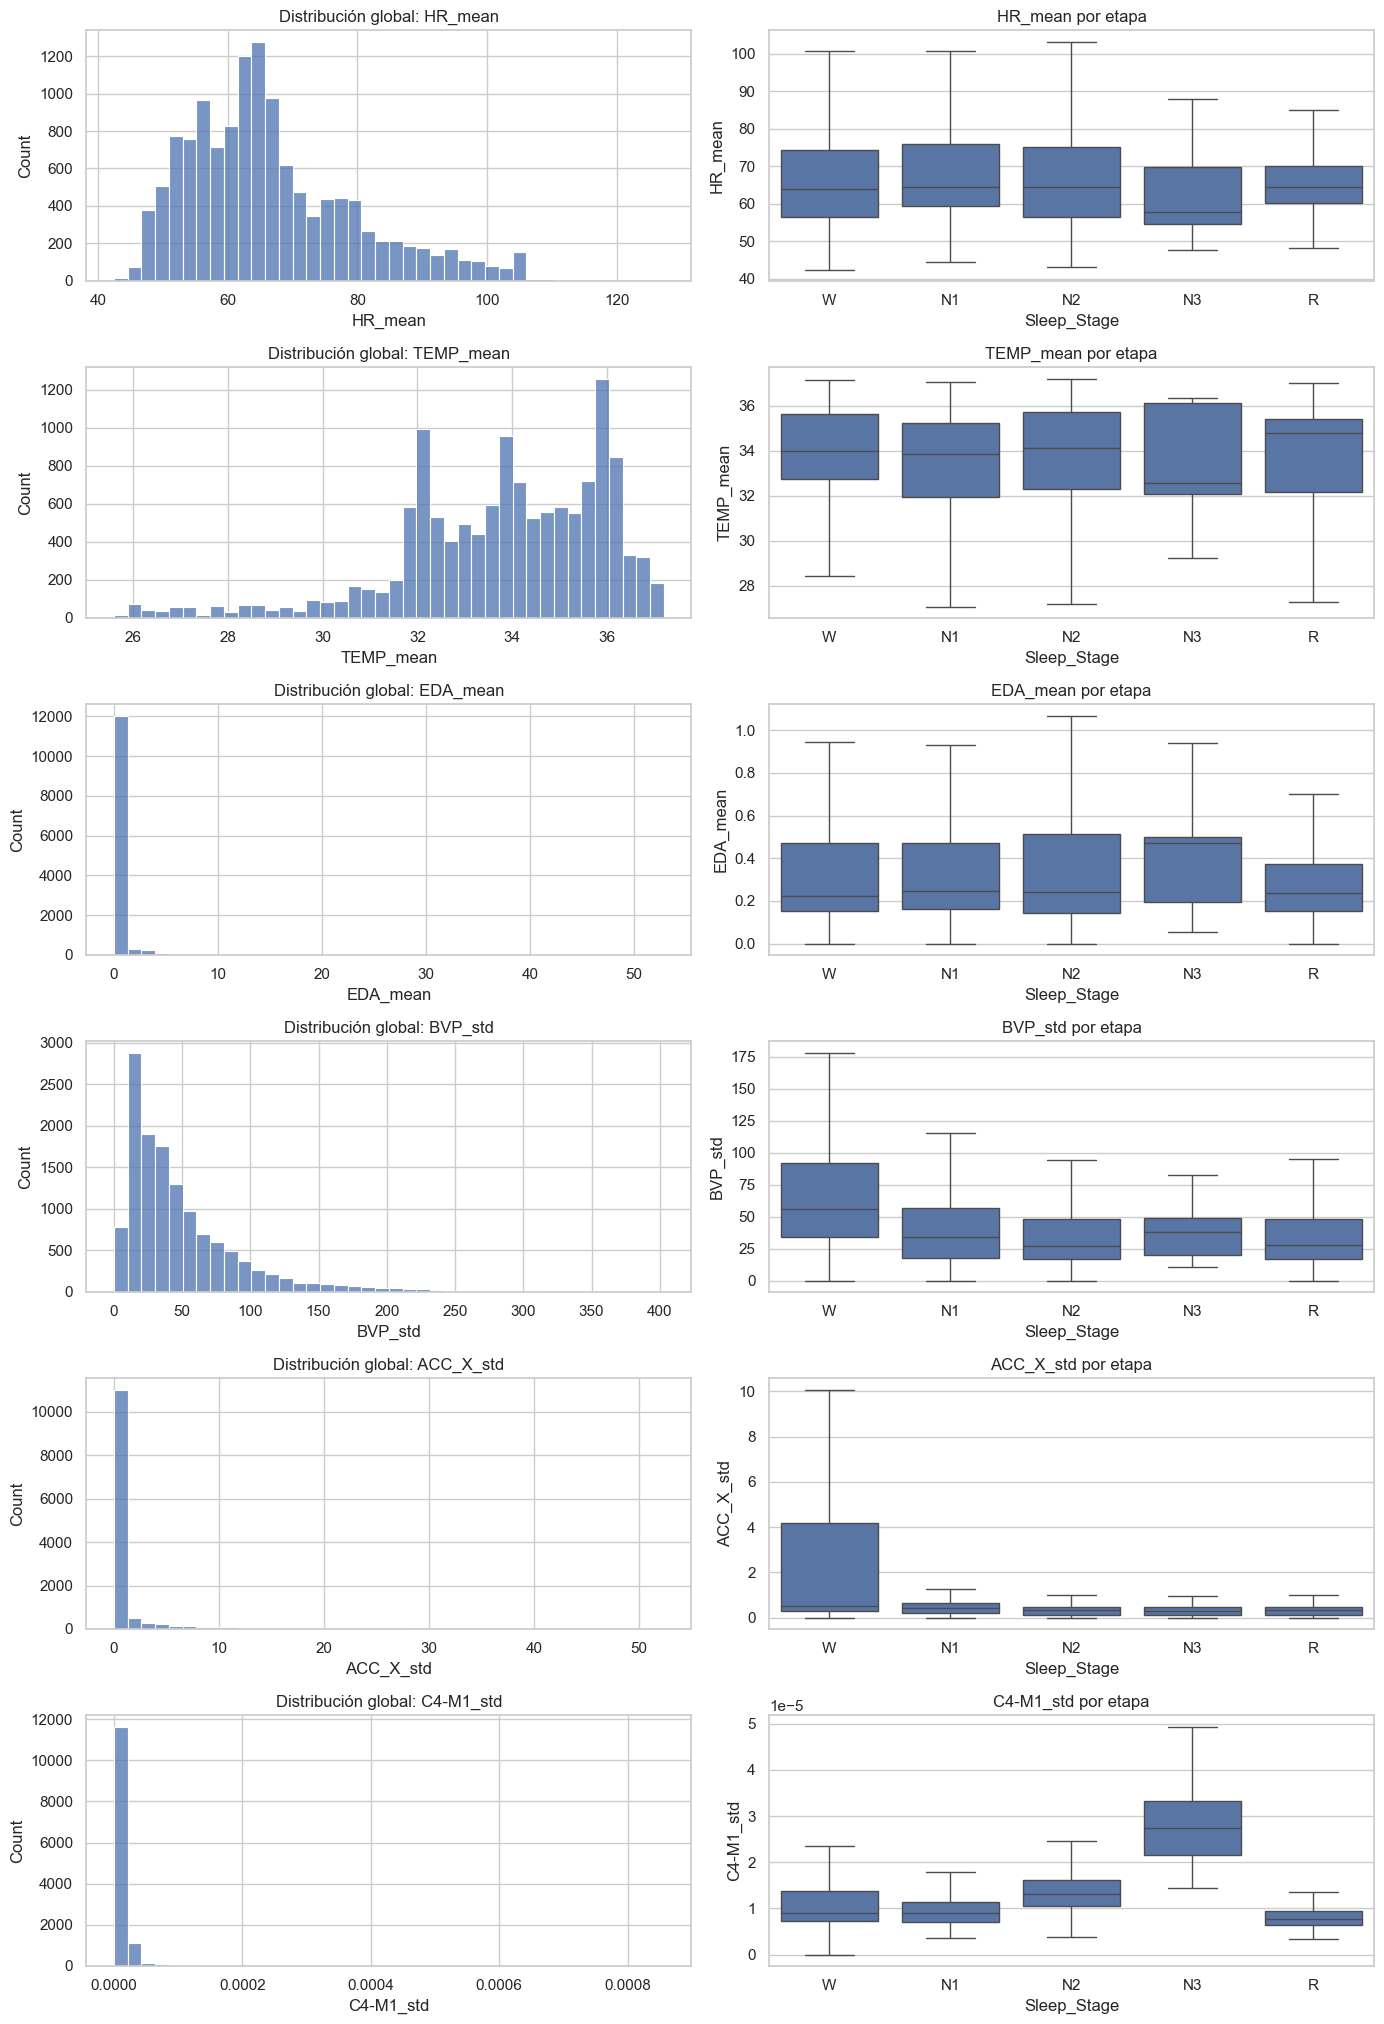

Los gráficos son descriptivos. No se transformaron predictores ni se balancearon etapas. Confirmar unidades antes de fijar umbrales.


In [40]:
# 3.3.2. Distribuciones de predictores prioritarios
candidatas_distribucion = [
    "HR_mean", "TEMP_mean", "EDA_mean", "BVP_std",
    "ACC_X_std", "C4-M1_std", "SAO2_mean",
]
variables_distribucion = [c for c in candidatas_distribucion
                          if c in df_epochs_all.columns]
if not variables_distribucion:
    raise ValueError("No hay predictores prioritarios disponibles.")

filas_cobertura = []
for variable in variables_distribucion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = df_epochs_all["Sleep_Stage"].eq(etapa)
        validos_etapa = finitos & en_etapa
        total_etapa = int(en_etapa.sum())
        filas_cobertura.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_con_valor": int(validos_etapa.sum()),
            "epochs_totales": total_etapa,
            "cobertura_pct": 100 * validos_etapa.sum() / total_etapa
                             if total_etapa else np.nan,
            "pacientes_con_valor": df_epochs_all.loc[
                validos_etapa, "patient_id"
            ].nunique(),
        })
resumen_distribuciones = pd.DataFrame(filas_cobertura)
print("COBERTURA POR VARIABLE Y ETAPA")
display(resumen_distribuciones.round(2))

fig, axes = plt.subplots(
    len(variables_distribucion), 2,
    figsize=(14, 3.4 * len(variables_distribucion)),
    squeeze=False,
)
for fila, variable in enumerate(variables_distribucion):
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    datos_grafico = df_epochs_all.loc[
        finitos, ["Sleep_Stage", variable]
    ]
    if datos_grafico.empty:
        axes[fila, 0].set_title(f"{variable}: sin valores finitos")
        axes[fila, 1].set_visible(False)
        continue
    sns.histplot(data=datos_grafico, x=variable, bins=40,
                 ax=axes[fila, 0])
    axes[fila, 0].set_title(f"Distribución global: {variable}")
    sns.boxplot(data=datos_grafico, x="Sleep_Stage", y=variable,
                order=["W", "N1", "N2", "N3", "R"],
                showfliers=False, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"{variable} por etapa")
plt.tight_layout()
plt.show()
print(
    "Los gráficos son descriptivos. No se transformaron predictores ni "
    "se balancearon etapas. Confirmar unidades antes de fijar umbrales."
)


## 3.4. Asociación entre señales y etapas

Los dos primeros mapas usan Spearman para revisar relaciones **entre predictores**; no miden relación con `Sleep_Stage`. Se eligen resúmenes con interpretación física y se excluyen identificadores, tiempo, anotaciones de apnea y numeraciones artificiales de la etapa. Las columnas ausentes se omiten sin inventar valores. Un par con |r| > 0,85 merece revisión de cobertura y redundancia, pero no se elimina automáticamente.

El tercer mapa compara cada etapa frente al resto mediante AUC de rangos. Se usa aquí como descripción univariada de la muestra, no como evaluación de un modelo ni criterio definitivo de selección. La comparación puede estar dominada por pacientes con más epochs; su estabilidad se comprobará después por paciente y fuera de muestra.


Cobertura de características incluidas en los mapas


,epochs_con_valor
BVP_std,13165
HR_mean,13165
HR_std,13165
EDA_mean,13165
EDA_std,13165
TEMP_mean,13165
ACC_X_std,13165
ACC_Y_std,13165
ACC_Z_std,13165
C4-M1_std,13165


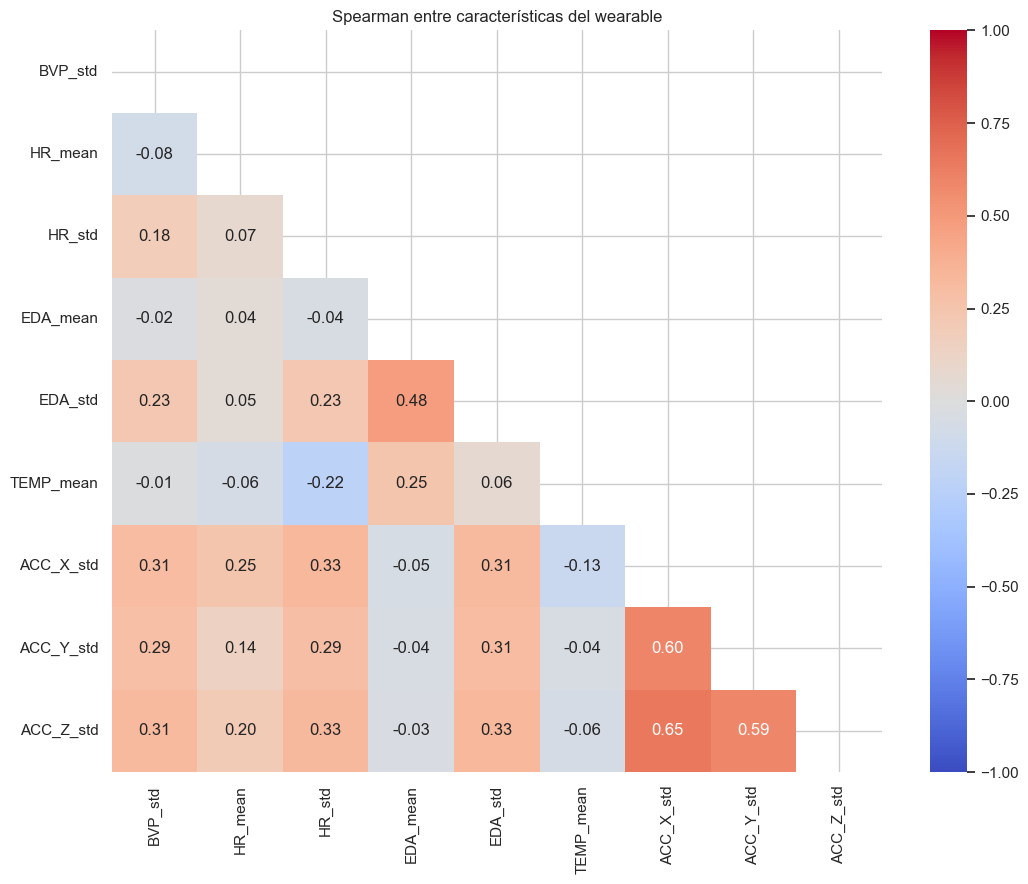

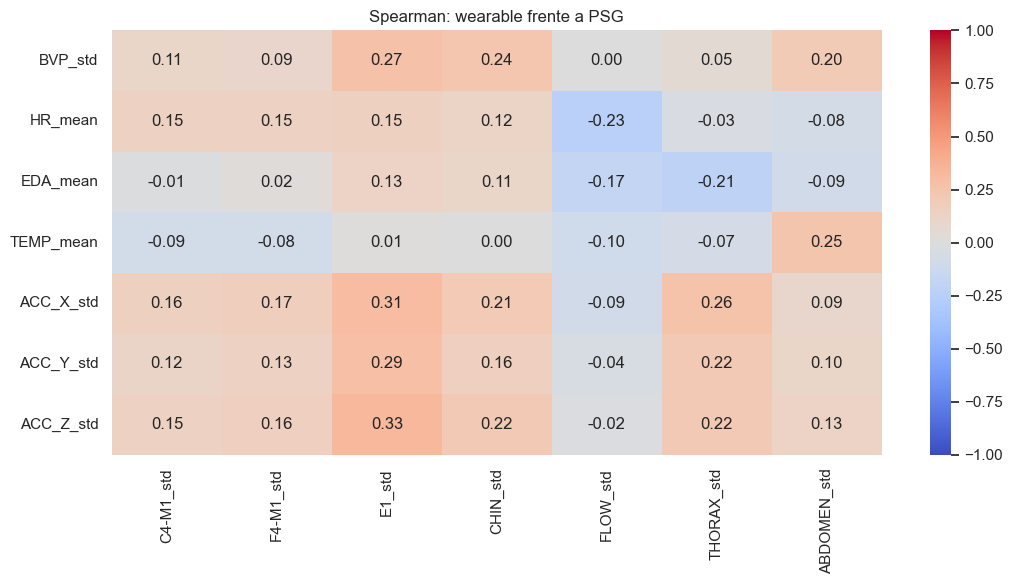

Pares con |Spearman| > 0,85: 5; ninguno se elimina


,variable_1,variable_2,spearman,magnitud
0,C4-M1_std,F4-M1_std,0.929931,0.929931
1,T3 - CZ_std,CZ - T4_std,0.905134,0.905134
2,C4-M1_std,T3 - CZ_std,0.862699,0.862699
3,C4-M1_std,CZ - T4_std,0.856628,0.856628
4,E1_std,E2_std,0.853632,0.853632


In [41]:
# 3.4.1. Asociaciones entre predictores, sin variable objetivo
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

wearable_mapa = [c for c in [
    "BVP_std", "HR_mean", "HR_std", "IBI_mean", "EDA_mean", "EDA_std",
    "TEMP_mean", "ACC_X_std", "ACC_Y_std", "ACC_Z_std", "SAO2_mean",
] if c in df_epochs_all.columns]
psg_mapa = [f"{senal}_std" for senal in psg_cols
            if f"{senal}_std" in df_epochs_all.columns]
caracteristicas_asociacion = wearable_mapa + psg_mapa
if len(caracteristicas_asociacion) < 2:
    raise ValueError("Faltan características para calcular asociaciones.")

print("Cobertura de características incluidas en los mapas")
display(df_epochs_all[caracteristicas_asociacion].notna().sum()
        .rename("epochs_con_valor").to_frame())

if len(wearable_mapa) > 1:
    corr_wearable = df_epochs_all[wearable_mapa].corr(
        method="spearman", min_periods=30
    )
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_wearable, mask=np.triu(np.ones_like(
        corr_wearable, dtype=bool)), annot=True, fmt=".2f",
        cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman entre características del wearable")
    plt.tight_layout()
    plt.show()

wearable_cruce = [c for c in [
    "BVP_std", "HR_mean", "EDA_mean", "TEMP_mean",
    "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in wearable_mapa]
psg_cruce = [c for c in [
    "C4-M1_std", "F4-M1_std", "E1_std", "CHIN_std",
    "FLOW_std", "THORAX_std", "ABDOMEN_std",
] if c in psg_mapa]
if wearable_cruce and psg_cruce:
    corr_cruce = df_epochs_all[wearable_cruce + psg_cruce].corr(
        method="spearman", min_periods=30
    ).loc[wearable_cruce, psg_cruce]
    plt.figure(figsize=(11, 6))
    sns.heatmap(corr_cruce, annot=True, fmt=".2f",
                cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman: wearable frente a PSG")
    plt.tight_layout()
    plt.show()

corr_predictores = df_epochs_all[caracteristicas_asociacion].corr(
    method="spearman", min_periods=30
)
triangulo = corr_predictores.where(np.triu(np.ones(
    corr_predictores.shape, dtype=bool), k=1))
pares_revisar = (
    triangulo.stack().rename("spearman").reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares_revisar = pares_revisar.loc[
    pares_revisar["spearman"].abs().gt(0.85)
].copy()
pares_revisar["magnitud"] = pares_revisar["spearman"].abs()
pares_revisar = pares_revisar.sort_values(
    "magnitud", ascending=False
).reset_index(drop=True)
print(f"Pares con |Spearman| > 0,85: {len(pares_revisar)}; ninguno se elimina")
display(pares_revisar.head(30))


### 3.4.2. Asociación descriptiva con cada etapa

Para cada característica se calcula una AUC de rangos de una etapa frente a las demás, usando únicamente epochs con valor finito. El mapa presenta `2 × AUC − 1`: **0** indica ausencia de separación por rangos; valores positivos indican valores mayores en esa etapa y negativos, menores. Las celdas sin ambas clases quedan vacías. La tabla adjunta informa cobertura, epochs y pacientes por etapa. Este análisis no presupone un orden entre W, N1, N2, N3 y R y no autoriza retirar columnas por sí solo.


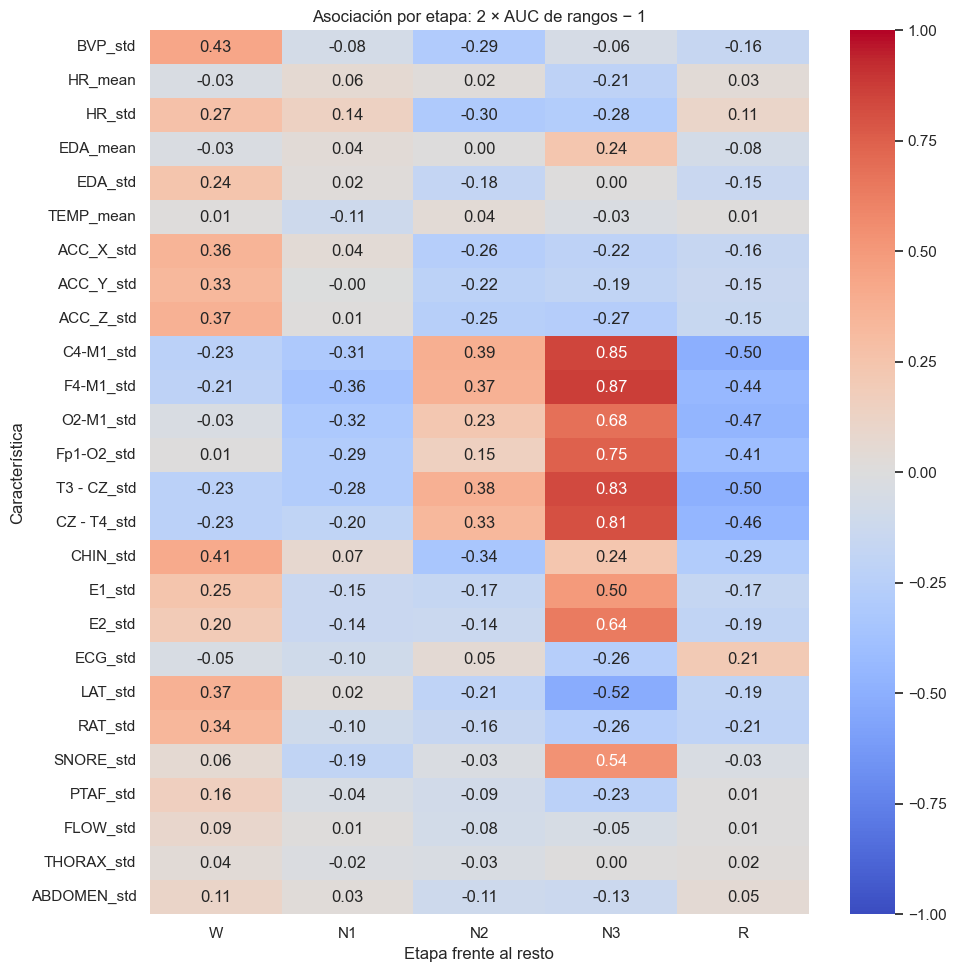

Detalle de cobertura y tamaños por etapa


,variable,Sleep_Stage,auc_rangos,direccion,epochs_etapa,epochs_resto,cobertura_pct,pacientes_etapa
0,BVP_std,W,0.716,0.431,4267,8898,100.0,18
1,BVP_std,N1,0.461,-0.078,1589,11576,100.0,18
2,BVP_std,N2,0.354,-0.292,5744,7421,100.0,18
3,BVP_std,N3,0.469,-0.061,438,12727,100.0,7
4,BVP_std,R,0.421,-0.157,1127,12038,100.0,14
...,...,...,...,...,...,...,...,...
125,ABDOMEN_std,W,0.557,0.115,4267,8898,100.0,18
126,ABDOMEN_std,N1,0.513,0.025,1589,11576,100.0,18
127,ABDOMEN_std,N2,0.445,-0.111,5744,7421,100.0,18
128,ABDOMEN_std,N3,0.435,-0.129,438,12727,100.0,7


0: sin separación univariada; positivo: valores mayores en la etapa; negativo: valores menores. Revisar cobertura y consistencia entre pacientes. Estas AUC no son rendimiento predictivo fuera de muestra.


In [42]:
# 3.4. Asociación por etapa: AUC de rangos uno contra el resto
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas inválidas o faltantes.")

filas_auc = []
for variable in caracteristicas_asociacion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    rangos = valores.loc[validos].rank(method="average")
    etapas_validas = df_epochs_all.loc[validos, "Sleep_Stage"]
    for etapa in orden_etapas:
        positivos = etapas_validas.eq(etapa)
        n_pos = int(positivos.sum())
        n_neg = int((~positivos).sum())
        auc = (
            (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
            / (n_pos * n_neg)
            if n_pos and n_neg else np.nan
        )
        filas_auc.append({
            "variable": variable, "Sleep_Stage": etapa,
            "auc_rangos": auc,
            "direccion": 2 * auc - 1 if pd.notna(auc) else np.nan,
            "epochs_etapa": n_pos, "epochs_resto": n_neg,
            "cobertura_pct": 100 * validos.mean(),
            "pacientes_etapa": df_epochs_all.loc[
                validos & df_epochs_all["Sleep_Stage"].eq(etapa), "patient_id"
            ].nunique(),
        })

resumen_auc_etapa = pd.DataFrame(filas_auc)
matriz_direccion = resumen_auc_etapa.pivot(
    index="variable", columns="Sleep_Stage", values="direccion"
).reindex(index=caracteristicas_asociacion, columns=orden_etapas)
if matriz_direccion.notna().any().any():
    plt.figure(figsize=(10, max(7, 0.38 * len(matriz_direccion))))
    sns.heatmap(matriz_direccion, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Asociación por etapa: 2 × AUC de rangos − 1")
    plt.xlabel("Etapa frente al resto")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()
else:
    print("No hay etapas con ambos grupos para calcular AUC de rangos.")

print("Detalle de cobertura y tamaños por etapa")
display(resumen_auc_etapa.round(3))
print(
    "0: sin separación univariada; positivo: valores mayores en la etapa; "
    "negativo: valores menores. Revisar cobertura y consistencia entre pacientes. "
    "Estas AUC no son rendimiento predictivo fuera de muestra."
)


**Interpretación del análisis de correlación:**

Las conclusiones se redactarán a partir de los mapas regenerados con el ETL actual. No se conservan coeficientes de versiones anteriores ni se interpreta REM como un nivel numérico de profundidad.

La relación descriptiva con cada etapa se muestra en el mapa de AUC de rangos y en las distribuciones globales de la sección 3.3. La utilidad predictiva deberá evaluarse después con pacientes separados.

## 3.5. Revisión de características y propuestas experimentales

La tabla siguiente reúne cobertura, variación, asociación descriptiva por etapa y marcas de revisión para las características del dataset base. Las medias y medianas de señales oscilatorias se **marcan para examinar**, no se eliminan. Después se resume si algunas diferencias por etapa mantienen su dirección entre pacientes, sin generar un gráfico por persona. Ninguno de estos criterios sustituye la comparación futura de modelos con partición por paciente. Las propuestas de ingeniería de características permanecen desactivadas y, si se habilitan más adelante, trabajarán sobre una copia.


### 3.5.1. Ficha de variables y consistencia entre pacientes

Cada fila de la primera tabla representa una característica existente. «Pendiente» significa que todavía no se decidió incluirla o excluirla del modelo. La marca de señal oscilatoria advierte que una media cercana a cero puede ser poco informativa sobre amplitud, pero no demuestra que la señal deba quitarse.

La segunda tabla compara, para cada paciente con al menos cinco epochs válidos en ambos grupos, la mediana de una etapa contra la mediana del resto. Informa cuántos pacientes permiten esa comparación y en qué proporción la diferencia tiene signo positivo. El umbral de cinco epochs es exploratorio para evitar interpretar una mediana de uno o dos epochs; no es un criterio clínico. No se asigna cero a pacientes sin esa etapa. La magnitud de diferencias entre señales con distintas unidades no es comparable.


In [43]:
# 3.5.1. Ficha descriptiva de características y estabilidad entre pacientes
if "resumen_auc_etapa" not in globals():
    raise ValueError("Ejecutar primero el mapa de asociación de la sección 3.4.")

columnas_revision = [c for c in df_epochs_all.columns
                     if c.endswith(("_mean", "_std", "_median"))]
filas_revision = []
for variable in columnas_revision:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    senal, estadistico = variable.rsplit("_", 1)
    marca = (
        "revisar resumen oscilatorio"
        if estadistico in ("mean", "median")
        and senal in set(psg_cols + ["BVP"])
        else "sin marca específica"
    )
    asociaciones = resumen_auc_etapa.loc[
        resumen_auc_etapa["variable"].eq(variable)
        & resumen_auc_etapa["direccion"].notna()
    ]
    mayor = (
        asociaciones.loc[asociaciones["direccion"].abs().idxmax()]
        if not asociaciones.empty else None
    )
    filas_revision.append({
        "variable": variable,
        "marca_revision": marca,
        "cobertura_pct": 100 * validos.mean(),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "valores_distintos": valores.loc[validos].nunique(),
        "iqr": valores.loc[validos].quantile(0.75)
               - valores.loc[validos].quantile(0.25) if validos.any() else np.nan,
        "etapa_mayor_asociacion": mayor["Sleep_Stage"] if mayor is not None else None,
        "direccion_mayor": mayor["direccion"] if mayor is not None else np.nan,
        "decision_modelo": "pendiente",
    })
revision_caracteristicas = pd.DataFrame(filas_revision)
print("FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA")
with pd.option_context("display.max_rows", 100):
    display(revision_caracteristicas.round(3))

variables_estabilidad = [c for c in [
    "HR_mean", "TEMP_mean", "EDA_mean", "BVP_std",
    "ACC_X_std", "C4-M1_std", "E1_std", "FLOW_std",
] if c in df_epochs_all.columns]
min_epochs_comparacion = 5
filas_estabilidad = []
for variable in variables_estabilidad:
    datos = df_epochs_all[["patient_id", "Sleep_Stage", variable]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.loc[np.isfinite(datos[variable])]
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = datos["Sleep_Stage"].eq(etapa)
        dentro = datos.loc[en_etapa].groupby("patient_id")[variable].agg(
            mediana_etapa="median", epochs_etapa="size"
        )
        fuera = datos.loc[~en_etapa].groupby("patient_id")[variable].agg(
            mediana_resto="median", epochs_resto="size"
        )
        pares = dentro.join(fuera, how="inner")
        pares = pares.loc[
            pares["epochs_etapa"].ge(min_epochs_comparacion)
            & pares["epochs_resto"].ge(min_epochs_comparacion)
        ]
        diferencias = pares["mediana_etapa"] - pares["mediana_resto"]
        filas_estabilidad.append({
            "variable": variable, "Sleep_Stage": etapa,
            "pacientes_evaluables": len(pares),
            "mediana_diferencia": diferencias.median() if len(pares) else np.nan,
            "pacientes_diferencia_positiva_pct":
                100 * diferencias.gt(0).mean() if len(pares) else np.nan,
        })
resumen_estabilidad = pd.DataFrame(filas_estabilidad)
print("DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA")
display(resumen_estabilidad.round(2))


FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA


,variable,marca_revision,cobertura_pct,pacientes_con_valor,valores_distintos,iqr,etapa_mayor_asociacion,direccion_mayor,decision_modelo
0,BVP_mean,revisar resumen oscilatorio,100.0,18,13164,0.342,None,NaN,pendiente
1,BVP_std,sin marca específica,100.0,18,13143,45.830,W,0.431,pendiente
2,BVP_median,revisar resumen oscilatorio,100.0,18,12670,5.176,None,NaN,pendiente
3,HR_mean,sin marca específica,100.0,18,13146,17.297,N3,-0.214,pendiente
4,HR_std,sin marca específica,100.0,18,13144,0.651,N2,-0.302,pendiente
5,HR_median,sin marca específica,100.0,18,3340,17.300,None,NaN,pendiente
6,EDA_mean,sin marca específica,100.0,18,13059,0.338,N3,0.240,pendiente
7,EDA_std,sin marca específica,100.0,18,13064,0.003,W,0.244,pendiente
8,EDA_median,sin marca específica,100.0,18,5242,0.338,None,NaN,pendiente
9,TEMP_mean,sin marca específica,100.0,18,12893,3.317,N1,-0.110,pendiente


DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA


,variable,Sleep_Stage,pacientes_evaluables,mediana_diferencia,pacientes_diferencia_positiva_pct
0,HR_mean,W,18,2.70,83.33
1,HR_mean,N1,18,0.27,50.00
2,HR_mean,N2,18,-0.74,38.89
3,HR_mean,N3,5,0.78,60.00
4,HR_mean,R,14,-1.46,28.57
5,TEMP_mean,W,18,-0.18,33.33
6,TEMP_mean,N1,18,-0.08,33.33
7,TEMP_mean,N2,18,0.05,55.56
8,TEMP_mean,N3,5,0.10,60.00
9,TEMP_mean,R,14,0.10,64.29


In [44]:
# Propuestas originales, pendientes de validación.
# Mantener False durante la preparación y auditoría del dataset.
APLICAR_FEATURE_ENGINEERING = False
df_epochs_features = None

if not APLICAR_FEATURE_ENGINEERING:
    print('Ingeniería experimental desactivada. df_epochs_all se conserva.')
elif 'df_epochs_all' not in globals() or df_epochs_all.empty:
    raise ValueError('Primero ejecutar la sección 3.1.')
else:
    df_epochs_features = df_epochs_all.copy()
    columnas_antes = set(df_epochs_features.columns)

    # Propuestas de poda sobre la copia; todavía no son selección validada.
    eliminar = ['tiempo_relativo_segundos', 'TIMESTAMP', 'Sleep_Stage_num']
    eliminar += [c for c in df_epochs_features.columns if c.endswith('_median')]

    psg_ac_channels = [
        'C4-M1', 'F4-M1', 'O2-M1', 'Fp1-O2', 'T3 - CZ', 'CZ - T4',
        'CHIN', 'E1', 'E2', 'ECG', 'LAT', 'RAT', 'SNORE', 'PTAF',
        'FLOW', 'THORAX', 'ABDOMEN'
    ]
    eliminar += [f'{c}_mean' for c in psg_ac_channels]
    eliminar += ['IBI_mean', 'IBI_std', 'IBI_median']
    df_epochs_features.drop(
        columns=[c for c in set(eliminar) if c in df_epochs_features.columns],
        inplace=True
    )

    # Promedio de resúmenes disponibles. No imputa las columnas originales.
    pares = {
        'EOG_combined_std': ['E1_std', 'E2_std'],
        'EEG_CF_M1_std': ['C4-M1_std', 'F4-M1_std'],
        'EEG_T_CZ_std': ['T3 - CZ_std', 'CZ - T4_std'],
        'LEG_combined_std': ['LAT_std', 'RAT_std']
    }
    for nueva, canales in pares.items():
        if all(c in df_epochs_features.columns for c in canales):
            df_epochs_features[nueva] = df_epochs_features[canales].mean(
                axis=1, skipna=True
            )
            df_epochs_features.drop(columns=canales, inplace=True)

    # Cociente experimental; no se presenta como índice clínico validado.
    if {'EOG_combined_std', 'CHIN_std'}.issubset(df_epochs_features.columns):
        df_epochs_features['EOG_CHIN_std_ratio'] = (
            df_epochs_features['EOG_combined_std']
            / (df_epochs_features['CHIN_std'] + 1e-5)
        )

    # Dispersión conjunta de los ejes, según la fórmula propuesta originalmente.
    ejes = ['ACC_X_std', 'ACC_Y_std', 'ACC_Z_std']
    if all(c in df_epochs_features.columns for c in ejes):
        df_epochs_features['ACC_axes_dispersion'] = np.sqrt(
            df_epochs_features[ejes].pow(2).sum(axis=1, skipna=False)
        )
        df_epochs_features.drop(
            columns=[c for c in ['ACC_X_mean', 'ACC_Y_mean', 'ACC_Z_mean']
                     if c in df_epochs_features.columns],
            inplace=True
        )

    print('Dimensiones originales:', df_epochs_all.shape)
    print('Dimensiones de la copia experimental:', df_epochs_features.shape)
    print('Columnas retiradas de la copia:',
          len(columnas_antes - set(df_epochs_features.columns)))
    print('Columnas candidatas nuevas:',
          sorted(set(df_epochs_features.columns) - columnas_antes))
    display(df_epochs_features.head())

Ingeniería experimental desactivada. df_epochs_all se conserva.


## 3.6. Variación de etapas entre pacientes

Esta sección resume todos los pacientes en una tabla y en gráficos globales; no genera un hipnograma por persona. Cada proporción usa los epochs conservados de ese paciente. La duración válida cuenta epochs conservados, mientras que el tramo observado entre el primero y el último también incluye posibles huecos. Una etapa ausente significa «no observada en los epochs conservados», no incapacidad fisiológica de alcanzarla.

La latencia REM se mide desde el **primer epoch de sueño observado** (N1, N2, N3 o R) hasta el primer epoch REM. Si REM no aparece, la latencia queda faltante y se informa «no observado»; no se reemplaza por cero. Las transiciones se cuentan solo entre etiquetas de epochs consecutivos. Un salto por epochs descartados se registra aparte y no se interpreta como transición directa. Proporciones, latencias y transiciones usan `Sleep_Stage` y son únicamente auditoría descriptiva: no pueden entrar como predictores del modelo de esa misma etiqueta. Ningún paciente se excluye por REM temprano, ausencia de REM o ausencia de N3.


PACIENTES RESUMIDOS: 18
SIN REM OBSERVADO: 4
SIN N3 OBSERVADO: 11
RESUMEN POR PACIENTE; SIN EXCLUSIONES


,patient_id,epochs_validos,duracion_valida_min,tramo_observado_min,saltos_entre_epochs,transiciones_contiguas,etapas_ausentes,estado_rem,latencia_rem_desde_primer_sueno_min,epochs_W,pct_W,epochs_N1,pct_N1,epochs_N2,pct_N2,epochs_N3,pct_N3,epochs_R,pct_R,HR_missing_frac_promedio,BVP_missing_frac_promedio,C4-M1_missing_frac_promedio,filas_fragmento_inicial,filas_fragmento_final,epochs_descartados_por_pureza,continuidad_temporal
0,2,652,326.0,326.0,0,188,N3,observado,159.5,174,26.687117,64,9.815951,334,51.226994,0,0.000000,80,12.269939,0.0,0.0,0.0,2400,0,0,verificada
1,3,773,386.5,386.5,0,72,ninguna,observado,96.0,58,7.503234,32,4.139715,428,55.368693,136,17.593790,119,15.394567,0.0,0.0,0.0,2400,0,0,verificada
2,4,804,402.0,402.0,0,274,R,no observado,NaN,216,26.865672,163,20.273632,424,52.736318,1,0.124378,0,0.000000,0.0,0.0,0.0,1100,0,0,verificada
3,5,730,365.0,365.0,0,121,ninguna,observado,98.0,90,12.328767,39,5.342466,480,65.753425,5,0.684932,116,15.890411,0.0,0.0,0.0,1300,0,0,verificada
4,6,801,400.5,400.5,0,191,R,no observado,NaN,210,26.217228,123,15.355805,290,36.204744,178,22.222222,0,0.000000,0.0,0.0,0.0,0,0,0,verificada
5,7,797,398.5,398.5,0,144,ninguna,observado,120.5,405,50.815558,26,3.262233,299,37.515684,26,3.262233,41,5.144291,0.0,0.0,0.0,0,0,0,verificada
6,8,743,371.5,371.5,0,104,ninguna,observado,41.5,53,7.133244,43,5.787349,421,56.662180,89,11.978466,137,18.438762,0.0,0.0,0.0,2500,0,0,verificada
7,9,766,383.0,383.0,0,110,ninguna,observado,113.5,211,27.545692,67,8.746736,409,53.394256,3,0.391645,76,9.921671,0.0,0.0,0.0,400,0,0,verificada
8,10,795,397.5,397.5,0,158,N3,observado,270.5,127,15.974843,124,15.597484,458,57.610063,0,0.000000,86,10.817610,0.0,0.0,0.0,100,0,0,verificada
9,16,750,375.0,375.0,0,103,N3,observado,156.0,226,30.133333,299,39.866667,169,22.533333,0,0.000000,56,7.466667,0.0,0.0,0.0,400,0,0,verificada


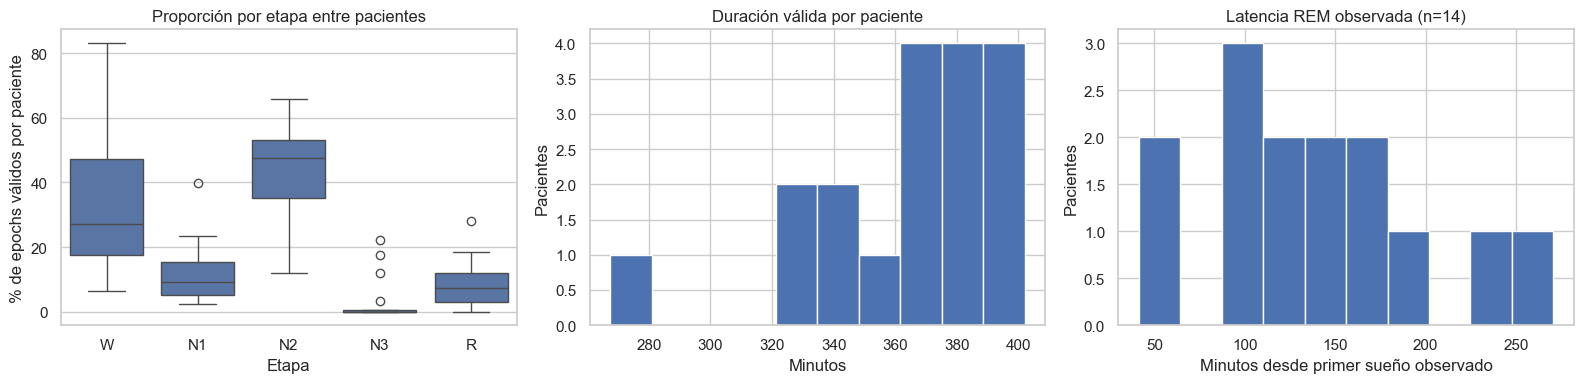

Los gráficos muestran variación descriptiva, no calidad del sueño ni un criterio de exclusión de pacientes.


In [45]:
# 3.6. Resumen descriptivo de etapas por paciente
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset consolidado de epochs.")
if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves paciente/epoch duplicadas.")
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas faltantes o inválidas.")

resumen_filas = []
for patient_id, grupo in df_epochs_all.groupby("patient_id", sort=True):
    grupo = grupo.sort_values("epoch")
    conteos = grupo["Sleep_Stage"].value_counts().reindex(
        orden_etapas, fill_value=0
    )
    primer_sueno = grupo.loc[
        grupo["Sleep_Stage"].ne("W"), "epoch"
    ].min()
    primer_rem = grupo.loc[
        grupo["Sleep_Stage"].eq("R"), "epoch"
    ].min()
    latencia_rem = (
        (primer_rem - primer_sueno) * 0.5
        if pd.notna(primer_sueno) and pd.notna(primer_rem) else np.nan
    )
    diferencias_epoch = grupo["epoch"].diff()
    transiciones = int((
        diferencias_epoch.eq(1)
        & grupo["Sleep_Stage"].ne(grupo["Sleep_Stage"].shift())
    ).sum())
    fila = {
        "patient_id": patient_id,
        "epochs_validos": len(grupo),
        "duracion_valida_min": len(grupo) * 0.5,
        "tramo_observado_min":
            (grupo["epoch"].max() - grupo["epoch"].min() + 1) * 0.5,
        "saltos_entre_epochs": int(diferencias_epoch.gt(1).sum()),
        "transiciones_contiguas": transiciones,
        "etapas_ausentes": ", ".join(conteos.index[conteos.eq(0)]) or "ninguna",
        "estado_rem": "observado" if pd.notna(primer_rem) else "no observado",
        "latencia_rem_desde_primer_sueno_min": latencia_rem,
    }
    for etapa in orden_etapas:
        fila[f"epochs_{etapa}"] = int(conteos[etapa])
        fila[f"pct_{etapa}"] = 100 * conteos[etapa] / len(grupo)
    for calidad in ["HR_missing_frac", "BVP_missing_frac", "C4-M1_missing_frac"]:
        if calidad in grupo.columns:
            fila[f"{calidad}_promedio"] = grupo[calidad].mean()
    resumen_filas.append(fila)

resumen_pacientes = pd.DataFrame(resumen_filas).sort_values(
    "patient_id"
).reset_index(drop=True)
if "auditoria_epochs" in globals():
    columnas_auditoria = [c for c in [
        "patient_id", "filas_fragmento_inicial", "filas_fragmento_final",
        "epochs_descartados_por_pureza", "continuidad_temporal",
    ] if c in auditoria_epochs.columns]
    if "patient_id" in columnas_auditoria:
        resumen_pacientes = resumen_pacientes.merge(
            auditoria_epochs[columnas_auditoria], on="patient_id",
            how="left", validate="one_to_one",
        )

print("PACIENTES RESUMIDOS:", len(resumen_pacientes))
print("SIN REM OBSERVADO:", resumen_pacientes["epochs_R"].eq(0).sum())
print("SIN N3 OBSERVADO:", resumen_pacientes["epochs_N3"].eq(0).sum())
print("RESUMEN POR PACIENTE; SIN EXCLUSIONES")
display(resumen_pacientes)

proporciones = resumen_pacientes.melt(
    id_vars="patient_id", value_vars=[f"pct_{e}" for e in orden_etapas],
    var_name="etapa", value_name="porcentaje_epochs",
)
proporciones["etapa"] = proporciones["etapa"].str.removeprefix("pct_")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=proporciones, x="etapa", y="porcentaje_epochs",
            order=orden_etapas, ax=axes[0], showfliers=True)
axes[0].set_title("Proporción por etapa entre pacientes")
axes[0].set_xlabel("Etapa")
axes[0].set_ylabel("% de epochs válidos por paciente")
axes[1].hist(resumen_pacientes["duracion_valida_min"].dropna())
axes[1].set_title("Duración válida por paciente")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Pacientes")
latencias_rem = resumen_pacientes[
    "latencia_rem_desde_primer_sueno_min"
].dropna()
if not latencias_rem.empty:
    axes[2].hist(latencias_rem)
axes[2].set_title(f"Latencia REM observada (n={len(latencias_rem)})")
axes[2].set_xlabel("Minutos desde primer sueño observado")
axes[2].set_ylabel("Pacientes")
plt.tight_layout()
plt.show()
print(
    "Los gráficos muestran variación descriptiva, no calidad del sueño "
    "ni un criterio de exclusión de pacientes."
)


## 3.7. Controles de rangos sin alterar el dataset

Se revisan reglas lógicas que no dependen de límites clínicos: desviaciones estándar no negativas, recuentos de muestras válidas entre 0 y 3000, fracciones de faltantes y pureza entre 0 y 1, y coherencia entre recuento y fracción de faltantes. El reporte indica epochs y pacientes afectados y conserva casos para inspección. **No corrige ni excluye filas**; una violación requiere volver al CSV fuente y justificar la causa antes de decidir tratamiento.

Por separado se describen ceros, cobertura, cuantiles y extremos observados de HR, TEMP, EDA, IBI y SAO2 cuando estén presentes. Estos números no son umbrales de recorte. En particular, no se comprueba `SAO2_mean` contra [0, 1] mientras no se confirme si la fuente usa fracción, porcentaje u otra escala. Tampoco se aplican máximos universales a BVP, aceleración o PSG. Las medias oscilatorias próximas a cero no son errores lógicos.


In [46]:
# 3.7. Controles lógicos de rangos, sin recorte
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset de epochs.")

reglas_rango = []
for col in df_epochs_all.columns:
    if col.endswith("_std"):
        reglas_rango.append((col, "desviación estándar negativa",
                             lambda v: v.lt(0)))
    elif col.endswith("_n_valid"):
        reglas_rango.append((col, "recuento fuera de [0, 3000] o no entero",
                             lambda v: v.lt(0) | v.gt(3000) | v.ne(v.round())))
    elif col.endswith("_missing_frac") or col == "porcentaje_pureza":
        reglas_rango.append((col, "fracción fuera de [0, 1]",
                             lambda v: v.lt(0) | v.gt(1)))

filas_controles = []
casos_controles = []
for variable, regla, criterio in reglas_rango:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    definidos = valores.notna()
    infraccion = definidos & (~np.isfinite(valores) | criterio(valores))
    filas_controles.append({
        "variable": variable, "regla": regla,
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~definidos).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = variable
        casos["regla"] = regla
        casos["valor"] = valores.loc[infraccion]
        casos_controles.append(casos)

for senal in [c.removesuffix("_n_valid") for c in df_epochs_all.columns
              if c.endswith("_n_valid")]:
    n_valid = pd.to_numeric(df_epochs_all[f"{senal}_n_valid"], errors="coerce")
    faltantes = pd.to_numeric(
        df_epochs_all[f"{senal}_missing_frac"], errors="coerce"
    )
    comparables = np.isfinite(n_valid) & np.isfinite(faltantes)
    infraccion = comparables & (
        faltantes.sub(1 - n_valid / 3000).abs().gt(1e-4)
    )
    filas_controles.append({
        "variable": senal,
        "regla": "recuento y fracción de faltantes inconsistentes",
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~comparables).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = senal
        casos["regla"] = "recuento y fracción de faltantes inconsistentes"
        casos["valor"] = faltantes.loc[infraccion]
        casos_controles.append(casos)

resumen_controles_rango = pd.DataFrame(filas_controles)
casos_controles_rango = (
    pd.concat(casos_controles, ignore_index=True)
    if casos_controles else pd.DataFrame(columns=[
        "patient_id", "epoch", "Sleep_Stage", "variable", "regla", "valor"
    ])
)
print("REGLAS LÓGICAS CON VIOLACIONES")
violaciones = resumen_controles_rango.loc[
    resumen_controles_rango["epochs_afectados"].gt(0)
]
display(violaciones if not violaciones.empty else "Sin violaciones detectadas")
print("CASOS PARA RASTREAR EN EL CSV FUENTE")
display(casos_controles_rango.head(20))
resumen_controles_etapa = (
    casos_controles_rango.groupby(["variable", "regla", "Sleep_Stage"])
    .agg(epochs_afectados=("epoch", "size"),
         pacientes_afectados=("patient_id", "nunique"))
    .reset_index()
)
print("VIOLACIONES POR ETAPA")
display(resumen_controles_etapa)

filas_niveles = []
for variable in [
    "HR_mean", "IBI_mean", "TEMP_mean", "EDA_mean", "SAO2_mean",
    "BVP_std", "ACC_X_std", "C4-M1_std",
]:
    if variable not in df_epochs_all.columns:
        continue
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    observados = valores.loc[validos]
    ceros = validos & valores.eq(0)
    filas_niveles.append({
        "variable": variable,
        "epochs_con_valor": int(validos.sum()),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "epochs_cero": int(ceros.sum()),
        "pacientes_con_ceros": df_epochs_all.loc[ceros, "patient_id"].nunique(),
        "minimo": observados.min(),
        "p01": observados.quantile(0.01),
        "mediana": observados.median(),
        "p99": observados.quantile(0.99),
        "maximo": observados.max(),
    })
resumen_niveles = pd.DataFrame(filas_niveles)
print("VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES")
display(resumen_niveles.round(3))
print("SAO2: escala pendiente de confirmación; no se aplica rango físico.")


REGLAS LÓGICAS CON VIOLACIONES


'Sin violaciones detectadas'

CASOS PARA RASTREAR EN EL CSV FUENTE


,patient_id,epoch,Sleep_Stage,variable,regla,valor


VIOLACIONES POR ETAPA


,variable,regla,Sleep_Stage,epochs_afectados,pacientes_afectados


VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES


,variable,epochs_con_valor,pacientes_con_valor,epochs_cero,pacientes_con_ceros,minimo,p01,mediana,p99,maximo
0,HR_mean,13165,18,0,0,42.391998,47.066,64.203003,104.961,127.278999
1,TEMP_mean,13165,18,0,0,25.594999,26.477,34.005001,36.955,37.195999
2,EDA_mean,13165,18,85,2,0.000000,0.005,0.238000,24.264,52.849998
3,BVP_std,13165,18,16,16,0.000000,1.708,36.431999,221.025,402.941010
4,ACC_X_std,13165,18,852,18,0.000000,0.000,0.396000,26.843,52.363998
5,C4-M1_std,13165,18,1,1,0.000000,0.000,0.000000,0.000,0.001000


SAO2: escala pendiente de confirmación; no se aplica rango físico.


### 3.8. Estado de la entrega ETL

| Decisión | Estado actual |
| :--- | :--- |
| Ventanas | 30 segundos (3000 muestras), alineadas por paciente. Solo se conservan epochs completos con una misma etiqueta válida en todas sus muestras. |
| Dataset | Un único `dataset_epochs_v1.csv`, ordenado por `patient_id` y `epoch`; no se generan datasets completos por paciente. |
| Trazabilidad | `auditoria_epochs.csv` documenta archivos, exclusiones, fragmentos, epochs conservados y descartados; `epochs_descartados.csv` detalla ventanas rechazadas. |
| Señales | 24 señales incluidas en esta versión, con media, desviación estándar, mediana y cobertura por epoch. IBI y SAO2 quedan fuera de las características hasta revisar disponibilidad y calidad. |
| Apneas | Las anotaciones permanecen en los CSV originales, pero no son predictores del modelo principal. |
| EDA | Se añadieron distribuciones, revisión de atípicos, mapas de asociación, fichas de características, variación entre pacientes y controles lógicos. Son análisis descriptivos; no prueban utilidad predictiva. |
| Transformaciones pendientes | No hay recorte de extremos, imputación, normalización, balanceo ni poda automática. La ingeniería experimental permanece desactivada. |
| Modelado | Diferido según ADR 0011; no se entrenó ni evaluó ningún algoritmo. |

La ejecución local con los **18 archivos disponibles** produjo **13.165 epochs y 126 columnas**, sin nulos ni epochs descartados. Los tres CSV se copiaron a `etl_v1/` dentro del proyecto; futuras ejecuciones locales guardarán allí directamente. Esta cohorte local todavía no cumple el mínimo de **50.000 filas**: faltan más pacientes o una ejecución con la cohorte definitiva. También resta interpretar auditoría y gráficos reales, confirmar unidades y documentar problemas antes de decidir tratamientos. El dataset base no se modificará por una correlación, un valor extremo o una etapa poco frecuente sin evidencia y decisión explícita.


# 4. Algoritmos
*(Espacio reservado para partición anti-leakage por paciente, selección de features y entrenamiento de modelos)*

# 5. Recopilación de resultados
*(Espacio reservado para métricas de evaluación, F1-Score Macro y matrices de confusión)*

# 6. Interpretación de resultados
*(Espacio reservado para análisis de importancia de variables e impacto clínico)*

# 7. Conclusiones
*(Espacio reservado para el cierre técnico del proyecto)*